# Notebook 01 — Exploratory Data Analysis (EDA)
**Project:** Huawei Telecom Complaint Analytics & Network Intelligence Platform  
**Deliverable:** D1 — EDA Report  
**Sources:** `real_complaints.xlsx` and `dataCollectionist.csv`

## 1. Setup & Chargement

In [1]:
# ── Cellule 1 — Setup & Imports ────────────────────────────────────────────

import sys, os
from pathlib import Path

# ── Project root ───────────────────────────────────────────────────────────
PROJECT_ROOT = r'C:\Users\c50057188\Desktop\PFE_Ouerghi'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

# ── Core libraries ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Jupyter display ────────────────────────────────────────────────────────
%matplotlib inline
plt.rcParams.update({
    'figure.dpi':       120,
    'figure.figsize':   (12, 5),
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
sns.set_theme(style='darkgrid', palette='husl')

# ── Color palettes ─────────────────────────────────────────────────────────
COLORS     = sns.color_palette('husl', 12)
HUAWEI_RED = '#CF0A2C'   # brand colour for highlights
C_DATA     = '#1A73E8'   # Data service
C_VOICE    = '#E74C3C'   # Voice service
C_NEUTRAL  = '#6B7280'   # Neutral / other

# ── Output directories ─────────────────────────────────────────────────────
FIGURES = Path('reports/figures')
EXPORTS = Path('reports/exports')
for d in [FIGURES, EXPORTS]:
    d.mkdir(parents=True, exist_ok=True)

print('✓  Setup complete')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   Project → {PROJECT_ROOT}')

✓  Setup complete
   pandas  2.3.3
   numpy   2.3.5
   Project → C:\Users\c50057188\Desktop\PFE_Ouerghi


In [2]:
# ── Cellule 2 — Data Loading ───────────────────────────────────────────────
from src.ingestion.real_data_loader import load_all_from_excel
from src.ingestion.data_collectionist_loader import load_collectionist

# ── Helper : infer operator from Tunisia MSISDN prefix ────────────────────
def infer_operator(msisdn_series: pd.Series) -> pd.Series:
    local = (msisdn_series.astype(str)
             .str.replace(r'^(00216|\+216|216)', '', regex=True)
             .str.strip())
    p2 = local.str[:2]
    p1 = local.str[:1]

    op = pd.Series('Unknown', index=msisdn_series.index)

    # ── Mobile ────────────────────────────────────────────────────────
    op[p2.str.match(r'^2\d$') | p2.str.match(r'^5[0-8]$')]          = 'Ooredoo'
    op[p2.str.match(r'^9\d$') | p2.isin(['40','41','42','44','46'])] = 'TunisieTelecom'
    op[local.between('43000000', '43009999')]                         = 'Orange'

    # ── Fixed / Box  (covers 36, 39 → Ooredoo; 48 → TunisieTelecom) ──
    op[(p1 == '3') & (op == 'Unknown')] = 'Ooredoo'
    op[(p1 == '7') & (op == 'Unknown')] = 'TunisieTelecom'
    op[(p1 == '4') & (op == 'Unknown')] = 'TunisieTelecom'   # 48, 49

    return op

# ── 1. real_complaints.xlsx ────────────────────────────────────────────────
data       = load_all_from_excel()
complaints = data['complaints']
kpi_data   = data['kpi_data_only']
kpi_voice  = data['kpi_voice_only']

complaints['operator'] = infer_operator(complaints['msisdn'])

# ── 2. dataCollectionist.csv ───────────────────────────────────────────────
dc = load_collectionist('data/raw/dataCollectionist.csv')
dc['operator'] = infer_operator(dc['msisdn'])

# ── Overview ───────────────────────────────────────────────────────────────
print('=' * 58)
print('  DATA SOURCES — OVERVIEW')
print('=' * 58)
print(f'  complaints (Sheet1)  : {complaints.shape[0]:>8,} × {complaints.shape[1]}')
print(f'  kpi_data   (DATA)    : {kpi_data.shape[0]:>8,} × {kpi_data.shape[1]}')
print(f'  kpi_voice  (VOICE)   : {kpi_voice.shape[0]:>8,} × {kpi_voice.shape[1]}')
print(f'  dataCollectionist    : {dc.shape[0]:>8,} × {dc.shape[1]}')

print('\n  Operator split — Sheet1 (complaints):')
for op, cnt in complaints['operator'].value_counts().items():
    print(f'    {op:<22} {cnt:>7,}  ({cnt/len(complaints)*100:.1f}%)')

print('\n  Operator split — dataCollectionist:')
for op, cnt in dc['operator'].value_counts().items():
    print(f'    {op:<22} {cnt:>7,}  ({cnt/len(dc)*100:.1f}%)')

print('=' * 58)

2026-05-16 16:12:45.233 | INFO     | src.ingestion.real_data_loader:load_all_from_excel:174 - Loading: data\raw\real_complaints.xlsx
2026-05-16 16:12:48.641 | INFO     | src.ingestion.real_data_loader:load_all_from_excel:177 -   Sheets found: ['Sheet1', 'DATA', 'VOICE']
2026-05-16 16:12:56.873 | INFO     | src.ingestion.real_data_loader:_load_sheet1:267 -   Sheet1 ('Sheet1'): 25,727 rows × 17 cols
2026-05-16 16:12:56.875 | DEBUG    | src.ingestion.real_data_loader:_load_sheet1:270 -   Raw columns: ['Case ID', 'system', 'case open datetime', 'Type', 'msisdn', 'last status', 'Provider Group', 'typologie It/network', 'category', 'sub category', 'sub sub category', 'province', 'city', 'Segment MSISDN CONCERN', 'bscs_custcode', 'account contact name', 'Week']
2026-05-16 16:12:56.896 | INFO     | src.ingestion.real_data_loader:_apply_mapping:625 -   Dropped (GDPR): ['account contact name']
2026-05-16 16:12:56.906 | INFO     | src.ingestion.real_data_loader:_apply_mapping:628 -   16 columns r

  DATA SOURCES — OVERVIEW
  complaints (Sheet1)  :   25,727 × 23
  kpi_data   (DATA)    :    3,806 × 13
  kpi_voice  (VOICE)   :    3,440 × 13
  dataCollectionist    :    4,898 × 129

  Operator split — Sheet1 (complaints):
    Ooredoo                 24,310  (94.5%)
    TunisieTelecom           1,327  (5.2%)
    Unknown                     90  (0.3%)

  Operator split — dataCollectionist:
    TunisieTelecom           4,367  (89.2%)
    Ooredoo                    529  (10.8%)
    Unknown                      2  (0.0%)


## 2. Sheet1 — EDA Plaintes

### 2.1 Vue d'ensemble

In [3]:
# ── Cellule 3 — Complaints EDA : Vue d'ensemble ────────────────────────────

# ── Column aliases ─────────────────────────────────────────────────────────
C_TIMESTAMP = 'timestamp'
C_TYPE      = 'service_type'           # Data / Voice
C_MSISDN    = 'msisdn'
C_STATUS    = 'resolution_status'
C_PROVIDER  = 'provider_group'
C_TYPOLOGY  = 'complaint_typology'    # IT vs Network
C_CATEGORY  = 'complaint_category'    # sub category  (motif réel)
C_SUBCAT    = 'complaint_subcategory' # sub sub category (détail)
C_REGION    = 'region'                # province
C_CITY      = 'city'
C_SEGMENT   = 'customer_segment'
C_WEEK      = 'week'
C_CASEID    = 'case_id'
C_PRIORITY  = 'priority'
# Derived by loader: hour | day_of_week | month | year | date | priority

# ── Guard: ensure temporal features are present ────────────────────────────
complaints[C_TIMESTAMP] = pd.to_datetime(complaints[C_TIMESTAMP], errors='coerce')
for col, expr in {
    'hour':        complaints[C_TIMESTAMP].dt.hour,
    'day_of_week': complaints[C_TIMESTAMP].dt.day_name(),
    'year':        complaints[C_TIMESTAMP].dt.year,
    'month':       complaints[C_TIMESTAMP].dt.month,
    'date':        complaints[C_TIMESTAMP].dt.date,
}.items():
    if col not in complaints.columns:
        complaints[col] = expr

# ── Overview ───────────────────────────────────────────────────────────────
print('=' * 50)
print('  SHEET1 — COMPLAINTS OVERVIEW')
print('=' * 50)
print(f'  Total complaints    : {len(complaints):,}')
print(f'  Period              : {complaints[C_TIMESTAMP].min().date()} → '
      f'{complaints[C_TIMESTAMP].max().date()}')
print(f'  Unique MSISDNs      : {complaints[C_MSISDN].nunique():,}')
print(f'  Regions             : {complaints[C_REGION].nunique()}')
print(f'  Cities              : {complaints[C_CITY].nunique()}')
print(f'  Complaint categories: {complaints[C_CATEGORY].nunique()}')
print(f'  Sub-categories      : {complaints[C_SUBCAT].nunique()}')
print()

# ── Operator split ─────────────────────────────────────────────────────────
print('  Operator split:')
for op, cnt in complaints['operator'].value_counts().items():
    print(f'    {op:<22} {cnt:>7,}  ({cnt/len(complaints)*100:.1f}%)')
print()

# ── Service type split ─────────────────────────────────────────────────────
print('  Service type:')
for svc, cnt in complaints[C_TYPE].value_counts().items():
    print(f'    {svc:<22} {cnt:>7,}  ({cnt/len(complaints)*100:.1f}%)')
print('=' * 50)

display(complaints[[C_CASEID, C_TIMESTAMP, C_TYPE, C_CATEGORY,
                    C_SUBCAT, C_REGION, C_CITY, C_SEGMENT,
                    C_PRIORITY, 'operator']].head(5))

  SHEET1 — COMPLAINTS OVERVIEW
  Total complaints    : 25,727
  Period              : 2025-01-01 → 2025-12-03
  Unique MSISDNs      : 22,226
  Regions             : 24
  Cities              : 257
  Complaint categories: 9
  Sub-categories      : 20

  Operator split:
    Ooredoo                 24,310  (94.5%)
    TunisieTelecom           1,327  (5.2%)
    Unknown                     90  (0.3%)

  Service type:
    Data                    13,685  (53.2%)
    Voice                   12,042  (46.8%)


,case_id,timestamp,service_type,complaint_category,complaint_subcategory,region,city,customer_segment,priority,operator
0,TT546791,2025-01-01 00:44:14,Data,Réclamation Réseau Mobile Data,Débit Faible Internet Mobile,Tunis Gouvernorat,Le Kram,Premium,Medium,Ooredoo
1,TT546829,2025-01-01 08:21:08,Voice,Réclamation Réseau Mobile Voix,Pas De Couverture Voix,Ben Arous Gouvernorat,Mornag,Lowenduser,Medium,Ooredoo
2,TT547176,2025-01-01 11:30:40,Data,Réclamation Réseau Mobile Data,Débit Faible Internet Mobile,Gafsa Gouvernorat,Gafsa,Lowenduser,Medium,Ooredoo
3,TT547218,2025-01-01 11:44:34,Voice,Réclamation Réseau Mobile Voix,Coupure Dappel,Sfax Gouvernorat,Sfax,Lowenduser,Medium,Ooredoo
4,TT547313,2025-01-01 12:29:53,Voice,Réclamation Réseau Mobile Voix,Echec Émission/Réception Appel,Sidi Bouzid Gouvernorat,Bir El Hafey,Hv,Medium,TunisieTelecom


### 2.2 Volume Over Time

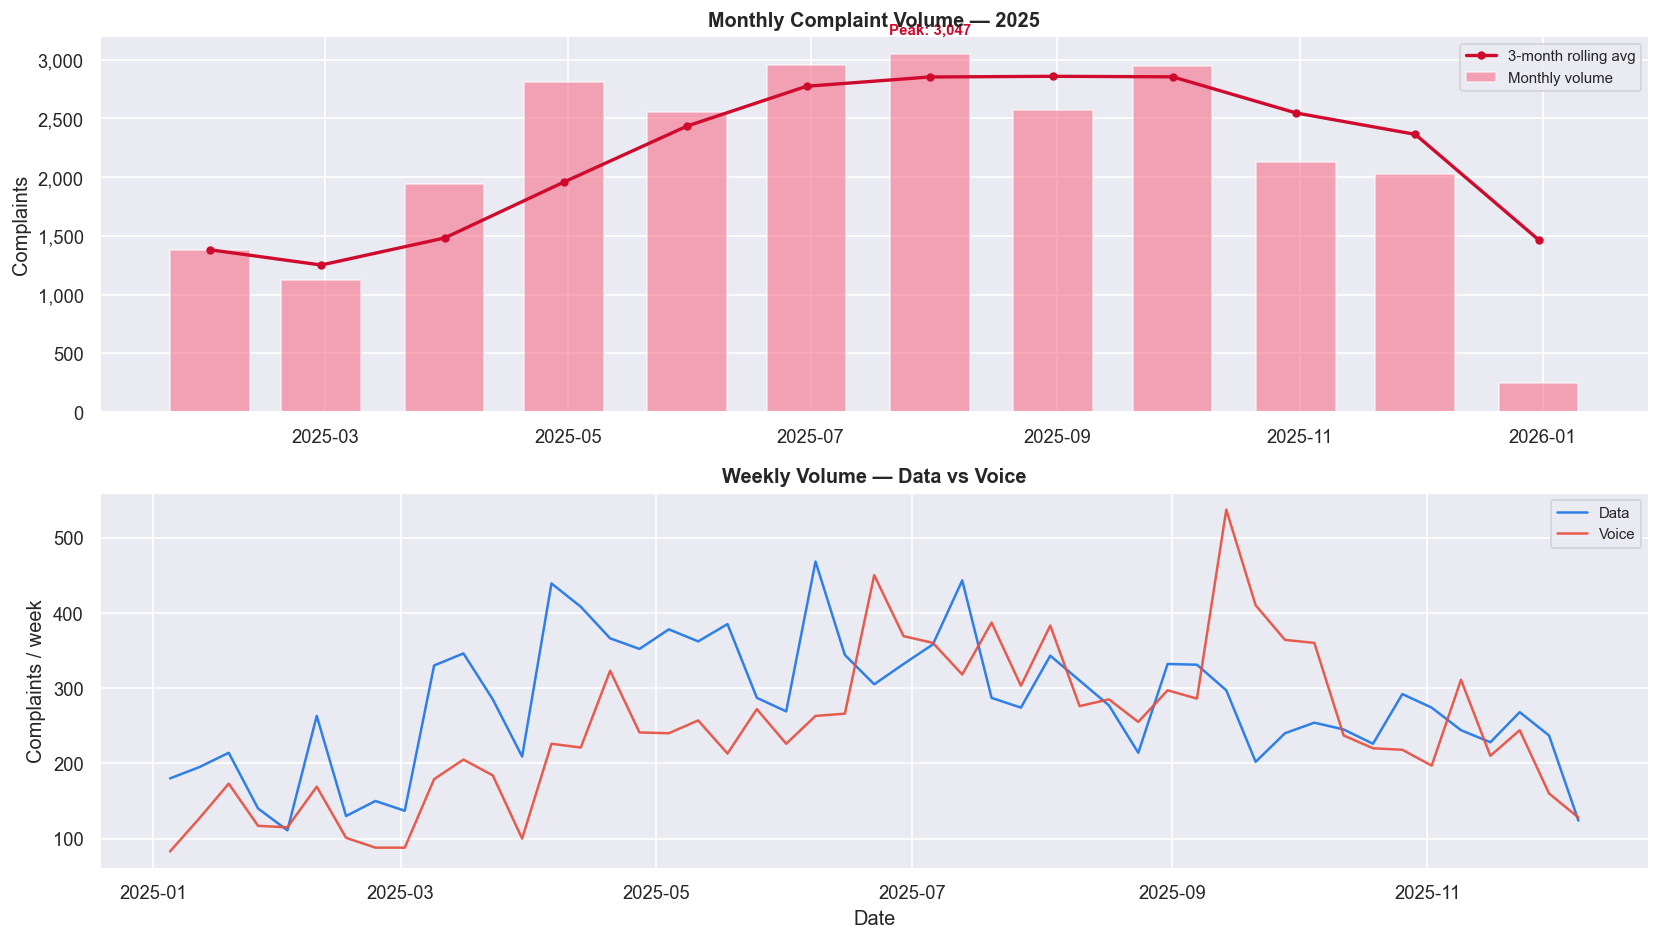

Peak month    : July 2025  (3,047 complaints)
Lowest month  : December 2025  (252 complaints)
Monthly avg   : 2,144 complaints


In [4]:
# ── Cellule 4 — Volume des plaintes dans le temps ─────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── 1. Monthly trend + rolling average ────────────────────────────────────
monthly = (complaints.set_index(C_TIMESTAMP)
                     .resample('ME').size()
                     .reset_index(name='count'))
monthly['roll3'] = monthly['count'].rolling(3, min_periods=1).mean()

ax = axes[0]
ax.bar(monthly[C_TIMESTAMP], monthly['count'],
       width=20, color=COLORS[0], alpha=0.6, label='Monthly volume')
ax.plot(monthly[C_TIMESTAMP], monthly['roll3'],
        linewidth=2, color=HUAWEI_RED, marker='o', markersize=4,
        label='3-month rolling avg')

# Annotate peak month
peak_idx = monthly['count'].idxmax()
peak_row = monthly.loc[peak_idx]
ax.annotate(f"Peak: {peak_row['count']:,}",
            xy=(peak_row[C_TIMESTAMP], peak_row['count']),
            xytext=(0, 12), textcoords='offset points',
            ha='center', fontsize=9, color=HUAWEI_RED, fontweight='bold')

ax.set_title('Monthly Complaint Volume — 2025', fontweight='bold')
ax.set_ylabel('Complaints')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=9)

# ── 2. Weekly trend split by service type ─────────────────────────────────
weekly = (complaints.groupby([pd.Grouper(key=C_TIMESTAMP, freq='W'), C_TYPE])
                    .size()
                    .unstack(fill_value=0)
                    .reset_index())

ax2 = axes[1]
if 'Data' in weekly.columns:
    ax2.plot(weekly[C_TIMESTAMP], weekly['Data'],
             linewidth=1.5, color=C_DATA, label='Data', alpha=0.9)
if 'Voice' in weekly.columns:
    ax2.plot(weekly[C_TIMESTAMP], weekly['Voice'],
             linewidth=1.5, color=C_VOICE, label='Voice', alpha=0.9)

ax2.set_title('Weekly Volume — Data vs Voice', fontweight='bold')
ax2.set_ylabel('Complaints / week')
ax2.set_xlabel('Date')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_complaint_volume_time.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────
print(f'Peak month    : {peak_row[C_TIMESTAMP].strftime("%B %Y")}  ({peak_row["count"]:,} complaints)')
print(f'Lowest month  : {monthly.loc[monthly["count"].idxmin(), C_TIMESTAMP].strftime("%B %Y")}  ({monthly["count"].min():,} complaints)')
print(f'Monthly avg   : {monthly["count"].mean():,.0f} complaints')

### 2.3 Service Type — Data vs Voice

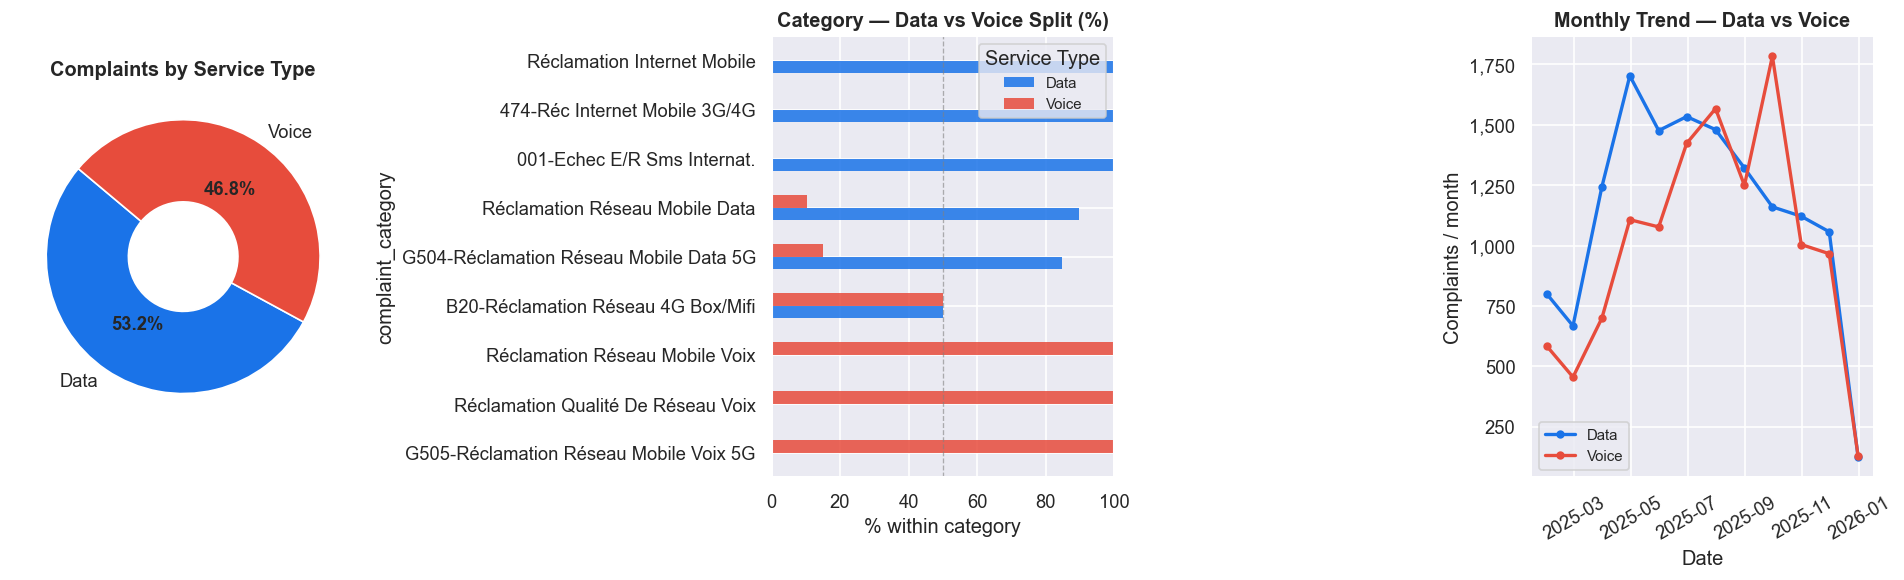

Service type breakdown:
  Data        13,685  (53.2%)
  Voice       12,042  (46.8%)


In [5]:
# ── Cellule 5 — Service Type Analysis ─────────────────────────────────────

if C_TYPE not in complaints.columns:
    print(f'Column "{C_TYPE}" not found'); 
else:
    counts = complaints[C_TYPE].value_counts()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── 1. Donut chart ─────────────────────────────────────────────────
    wedge_colors = [C_DATA if s == 'Data' else C_VOICE
                    for s in counts.index]
    wedges, texts, autotexts = axes[0].pie(
        counts, labels=counts.index,
        autopct='%1.1f%%', colors=wedge_colors,
        startangle=140, wedgeprops=dict(width=0.6),   # donut
        textprops=dict(fontsize=11),
    )
    for at in autotexts:
        at.set_fontweight('bold')
    axes[0].set_title('Complaints by Service Type', fontweight='bold')

    # ── 2. Category × Service Type split (%) ──────────────────────────
    if C_CATEGORY in complaints.columns:
        ct = (pd.crosstab(complaints[C_CATEGORY], complaints[C_TYPE],
                          normalize='index')
                .mul(100).round(1)
                .sort_values('Data', ascending=True))

        ct.plot(kind='barh', ax=axes[1],
                color=[C_DATA, C_VOICE][:len(ct.columns)],
                alpha=0.85, edgecolor='none')
        axes[1].axvline(50, color='gray', linestyle='--',
                        linewidth=0.8, alpha=0.6)
        axes[1].set_title('Category — Data vs Voice Split (%)',
                          fontweight='bold')
        axes[1].set_xlabel('% within category')
        axes[1].set_xlim(0, 100)
        axes[1].legend(title='Service Type', fontsize=9)

    # ── 3. Monthly trend by service type ──────────────────────────────
    monthly_svc = (
        complaints.groupby([pd.Grouper(key=C_TIMESTAMP, freq='ME'), C_TYPE])
                  .size().unstack(fill_value=0).reset_index()
    )
    for svc, color in [('Data', C_DATA), ('Voice', C_VOICE)]:
        if svc in monthly_svc.columns:
            axes[2].plot(monthly_svc[C_TIMESTAMP], monthly_svc[svc],
                         linewidth=2, color=color,
                         marker='o', markersize=4, label=svc)
    axes[2].set_title('Monthly Trend — Data vs Voice', fontweight='bold')
    axes[2].set_xlabel('Date')
    axes[2].set_ylabel('Complaints / month')
    axes[2].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[2].legend(fontsize=9)
    axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_service_type.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────
    print('Service type breakdown:')
    for svc, cnt in counts.items():
        print(f'  {svc:<10} {cnt:>7,}  ({cnt/len(complaints)*100:.1f}%)')

### 2.4 Typology — IT vs Network

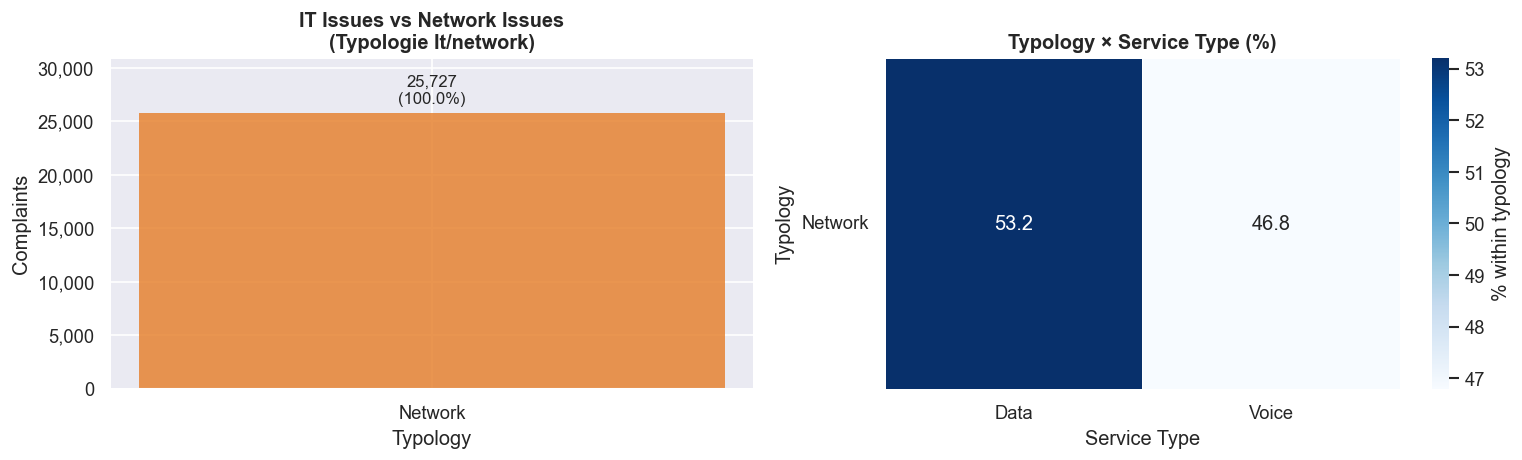

Typology breakdown:
  Network               25,727  (100.0%)


In [6]:
# ── Cellule 6 — Typology: IT vs Network ───────────────────────────────────

if C_TYPOLOGY not in complaints.columns:
    print(f'Column "{C_TYPOLOGY}" not found')
else:
    counts = complaints[C_TYPOLOGY].value_counts()
    total  = len(complaints)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── 1. Bar chart global ────────────────────────────────────────────
    bars = axes[0].bar(
        counts.index, counts.values,
        color=[COLORS[1], COLORS[3]][:len(counts)],
        edgecolor='none', alpha=0.85
    )
    axes[0].bar_label(bars,
                      labels=[f'{v:,}\n({v/total*100:.1f}%)'
                               for v in counts.values],
                      padding=4, fontsize=10)
    axes[0].set_title('IT Issues vs Network Issues\n(Typologie It/network)',
                      fontweight='bold')
    axes[0].set_xlabel('Typology')
    axes[0].set_ylabel('Complaints')
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[0].set_ylim(0, counts.max() * 1.20)  # room for labels

    # ── 2. Typology × Service Type heatmap ────────────────────────────
    if C_TYPE in complaints.columns:
        ct = pd.crosstab(complaints[C_TYPOLOGY], complaints[C_TYPE])
        ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)

        sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues',
                    linewidths=0.4, ax=axes[1],
                    cbar_kws={'label': '% within typology'})
        axes[1].set_title('Typology × Service Type (%)',
                          fontweight='bold')
        axes[1].set_xlabel('Service Type')
        axes[1].set_ylabel('Typology')
        axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_typology.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────
    print('Typology breakdown:')
    for typ, cnt in counts.items():
        print(f'  {typ:<20} {cnt:>7,}  ({cnt/total*100:.1f}%)')

### 2.5 Resolution Status

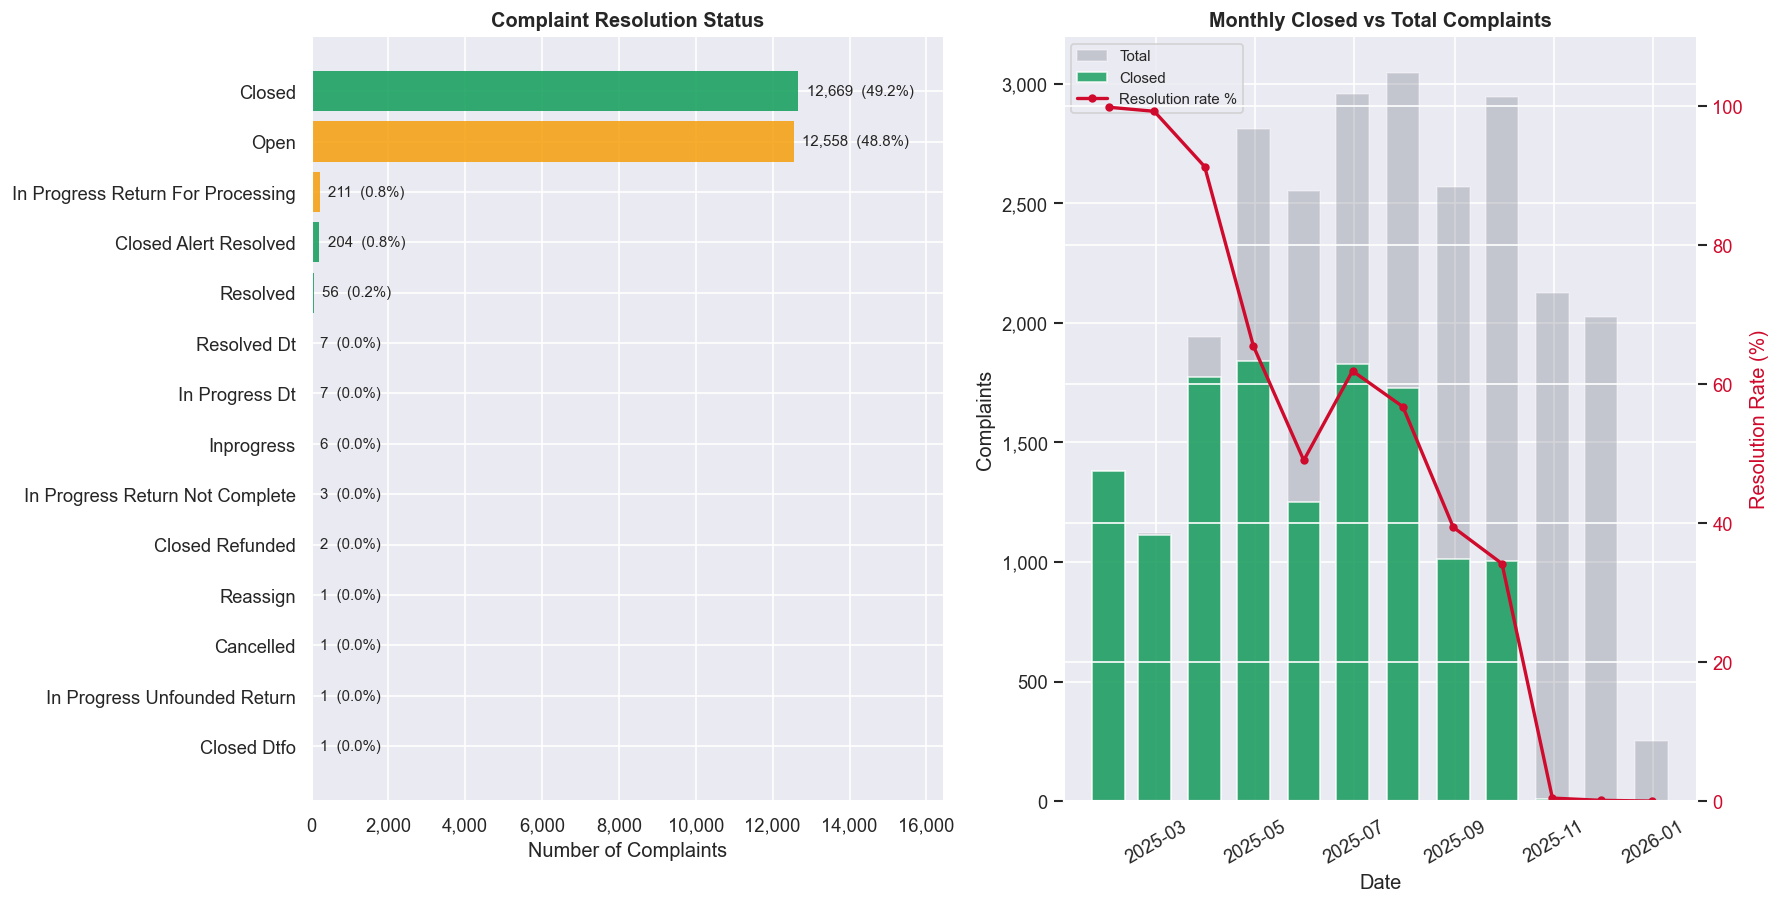

Resolution rate (avg) : 49.8%

Status breakdown:
  Closed                          12,669  (49.2%)
  Open                            12,558  (48.8%)
  In Progress Return For Processing     211  (0.8%)
  Closed Alert Resolved              204  (0.8%)
  Resolved                            56  (0.2%)
  In Progress Dt                       7  (0.0%)
  Resolved Dt                          7  (0.0%)
  Inprogress                           6  (0.0%)
  In Progress Return Not Complete       3  (0.0%)
  Closed Refunded                      2  (0.0%)
  Closed Dtfo                          1  (0.0%)
  In Progress Unfounded Return         1  (0.0%)
  Cancelled                            1  (0.0%)
  Reassign                             1  (0.0%)


In [7]:
# ── Cellule 7 — Resolution Status ─────────────────────────────────────────

if C_STATUS not in complaints.columns:
    print(f'Column "{C_STATUS}" not found')
else:
    counts = (complaints[C_STATUS].value_counts()
                                  .sort_values(ascending=True))
    total  = len(complaints)

    # ── Semantic colors: closed=green, open/pending=amber, unknown=gray ─
    def status_color(label: str) -> str:
        l = label.lower()
        if any(k in l for k in ['closed', 'resolved', 'fermé', 'résolu', 'clôturé']):
            return '#0F9D58'
        if any(k in l for k in ['open', 'pending', 'ouvert', 'en cours', 'progress']):
            return '#F59E0B'
        return C_NEUTRAL

    colors = [status_color(s) for s in counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(15, max(4, len(counts) * 0.55)))

    # ── 1. Horizontal bar chart ────────────────────────────────────────
    bars = axes[0].barh(counts.index, counts.values,
                        color=colors, edgecolor='none', alpha=0.85)
    axes[0].bar_label(bars,
                      labels=[f'{v:,}  ({v/total*100:.1f}%)'
                               for v in counts.values],
                      padding=5, fontsize=9)
    axes[0].set_xlim(0, counts.values.max() * 1.30)
    axes[0].set_title('Complaint Resolution Status',
                      fontweight='bold')
    axes[0].set_xlabel('Number of Complaints')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # ── 2. Monthly resolution rate (closed vs total) ───────────────────
    # Identify closed statuses dynamically
    closed_mask = complaints[C_STATUS].str.lower().str.contains(
        'closed|resolved|fermé|résolu|clôturé', na=False
    )
    monthly_total  = (complaints
                      .set_index(C_TIMESTAMP)
                      .resample('ME').size())
    monthly_closed = (complaints[closed_mask]
                      .set_index(C_TIMESTAMP)
                      .resample('ME').size()
                      .reindex(monthly_total.index, fill_value=0))
    resolution_rate = (monthly_closed / monthly_total * 100).fillna(0)

    axes[1].bar(monthly_total.index, monthly_total.values,
                width=20, color=C_NEUTRAL, alpha=0.3, label='Total')
    axes[1].bar(monthly_closed.index, monthly_closed.values,
                width=20, color='#0F9D58', alpha=0.8, label='Closed')
    ax2 = axes[1].twinx()
    ax2.plot(resolution_rate.index, resolution_rate.values,
             color=HUAWEI_RED, linewidth=2, marker='o',
             markersize=4, label='Resolution rate %')
    ax2.set_ylabel('Resolution Rate (%)', color=HUAWEI_RED)
    ax2.tick_params(axis='y', labelcolor=HUAWEI_RED)
    ax2.set_ylim(0, 110)

    axes[1].set_title('Monthly Closed vs Total Complaints',
                      fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Complaints')
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[1].tick_params(axis='x', rotation=30)

    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_resolution_status.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────
    avg_rate = resolution_rate.mean()
    print(f'Resolution rate (avg) : {avg_rate:.1f}%')
    print(f'\nStatus breakdown:')
    for s, cnt in complaints[C_STATUS].value_counts().items():
        print(f'  {s:<30} {cnt:>7,}  ({cnt/total*100:.1f}%)')

### 2.6 Provider Group

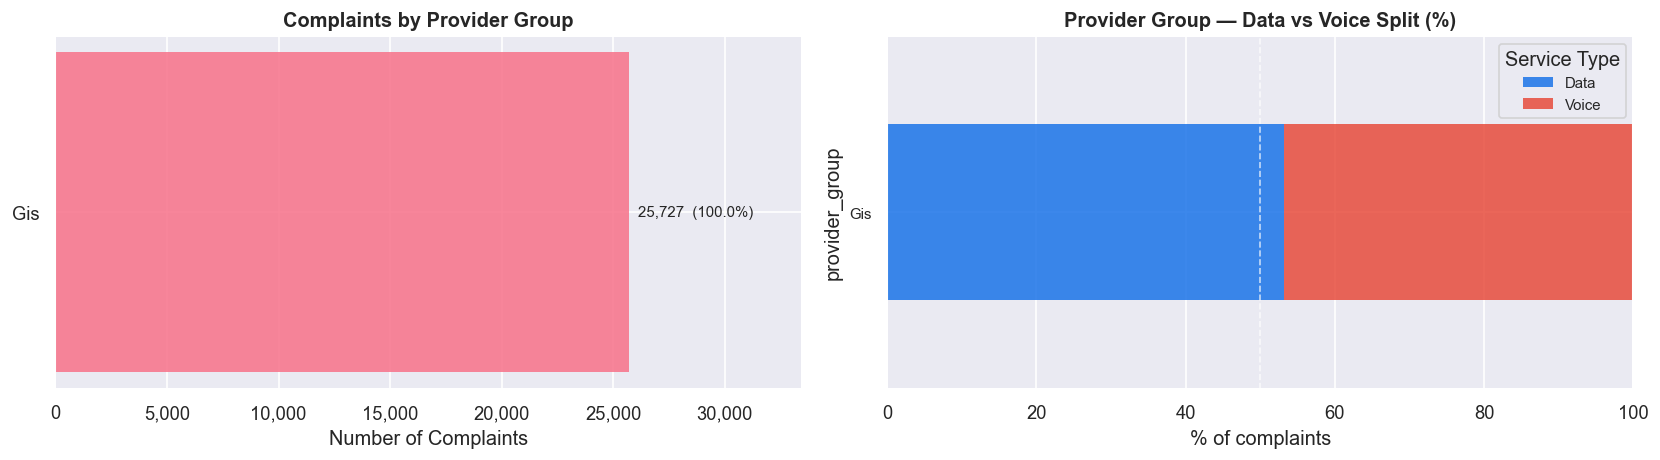

Provider Group breakdown:
  Gis                        25,727  (100.0%)


In [8]:
# ── Cellule 8 — Provider Group ─────────────────────────────────────────────

if C_PROVIDER not in complaints.columns:
    print(f'Column "{C_PROVIDER}" not found')
else:
    counts = complaints[C_PROVIDER].value_counts().sort_values(ascending=True)
    total  = len(complaints)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(counts) * 0.6)))

    # ── 1. Horizontal bar — count + % ─────────────────────────────────
    bars = axes[0].barh(
        counts.index, counts.values,
        color=[COLORS[i % len(COLORS)] for i in range(len(counts))],
        edgecolor='none', alpha=0.85
    )
    axes[0].bar_label(bars,
                      labels=[f'{v:,}  ({v/total*100:.1f}%)'
                               for v in counts.values],
                      padding=5, fontsize=9)
    axes[0].set_xlim(0, counts.max() * 1.30)
    axes[0].set_title('Complaints by Provider Group', fontweight='bold')
    axes[0].set_xlabel('Number of Complaints')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # ── 2. Provider × Service Type stacked bar ─────────────────────────
    if C_TYPE in complaints.columns:
        ct = pd.crosstab(complaints[C_PROVIDER], complaints[C_TYPE])
        ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
        # Sort by same order as left chart
        ct_pct = ct_pct.reindex(counts.index)

        ct_pct.plot(
            kind='barh', stacked=True, ax=axes[1],
            color=[C_DATA, C_VOICE][:len(ct_pct.columns)],
            edgecolor='none', alpha=0.85
        )
        axes[1].axvline(50, color='white', linestyle='--',
                        linewidth=1, alpha=0.7)
        axes[1].set_title('Provider Group — Data vs Voice Split (%)',
                          fontweight='bold')
        axes[1].set_xlabel('% of complaints')
        axes[1].set_xlim(0, 100)
        axes[1].legend(title='Service Type', fontsize=9)
        axes[1].tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_provider_group.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────
    print('Provider Group breakdown:')
    for prov, cnt in complaints[C_PROVIDER].value_counts().items():
        print(f'  {prov:<25} {cnt:>7,}  ({cnt/total*100:.1f}%)')

### 2.7 Geographic Distribution (Province & City)

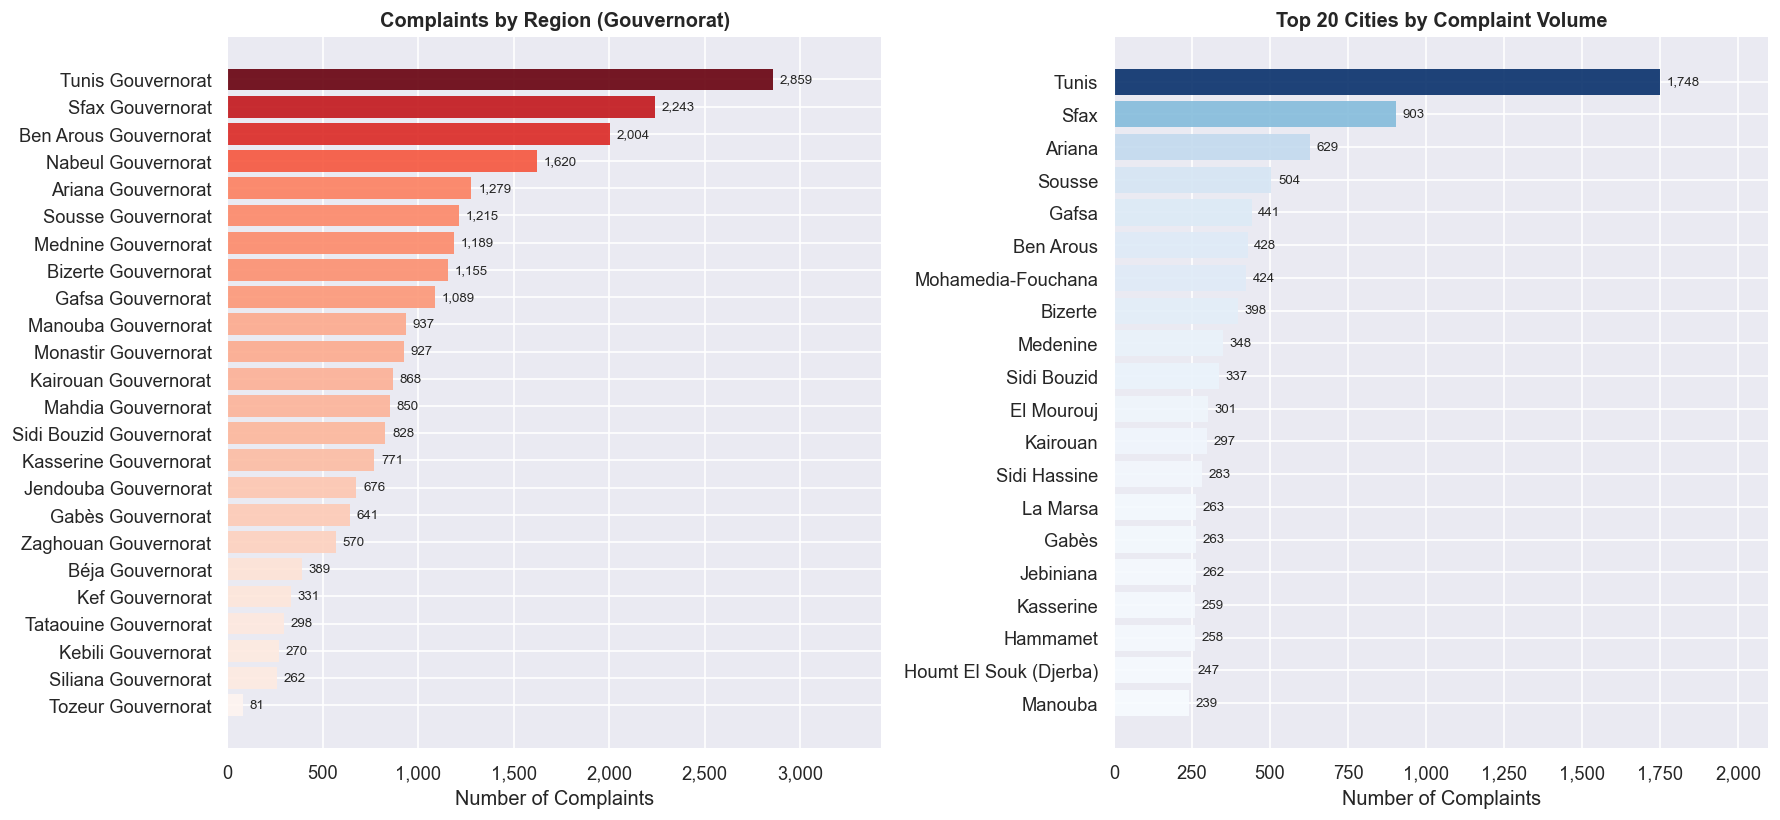

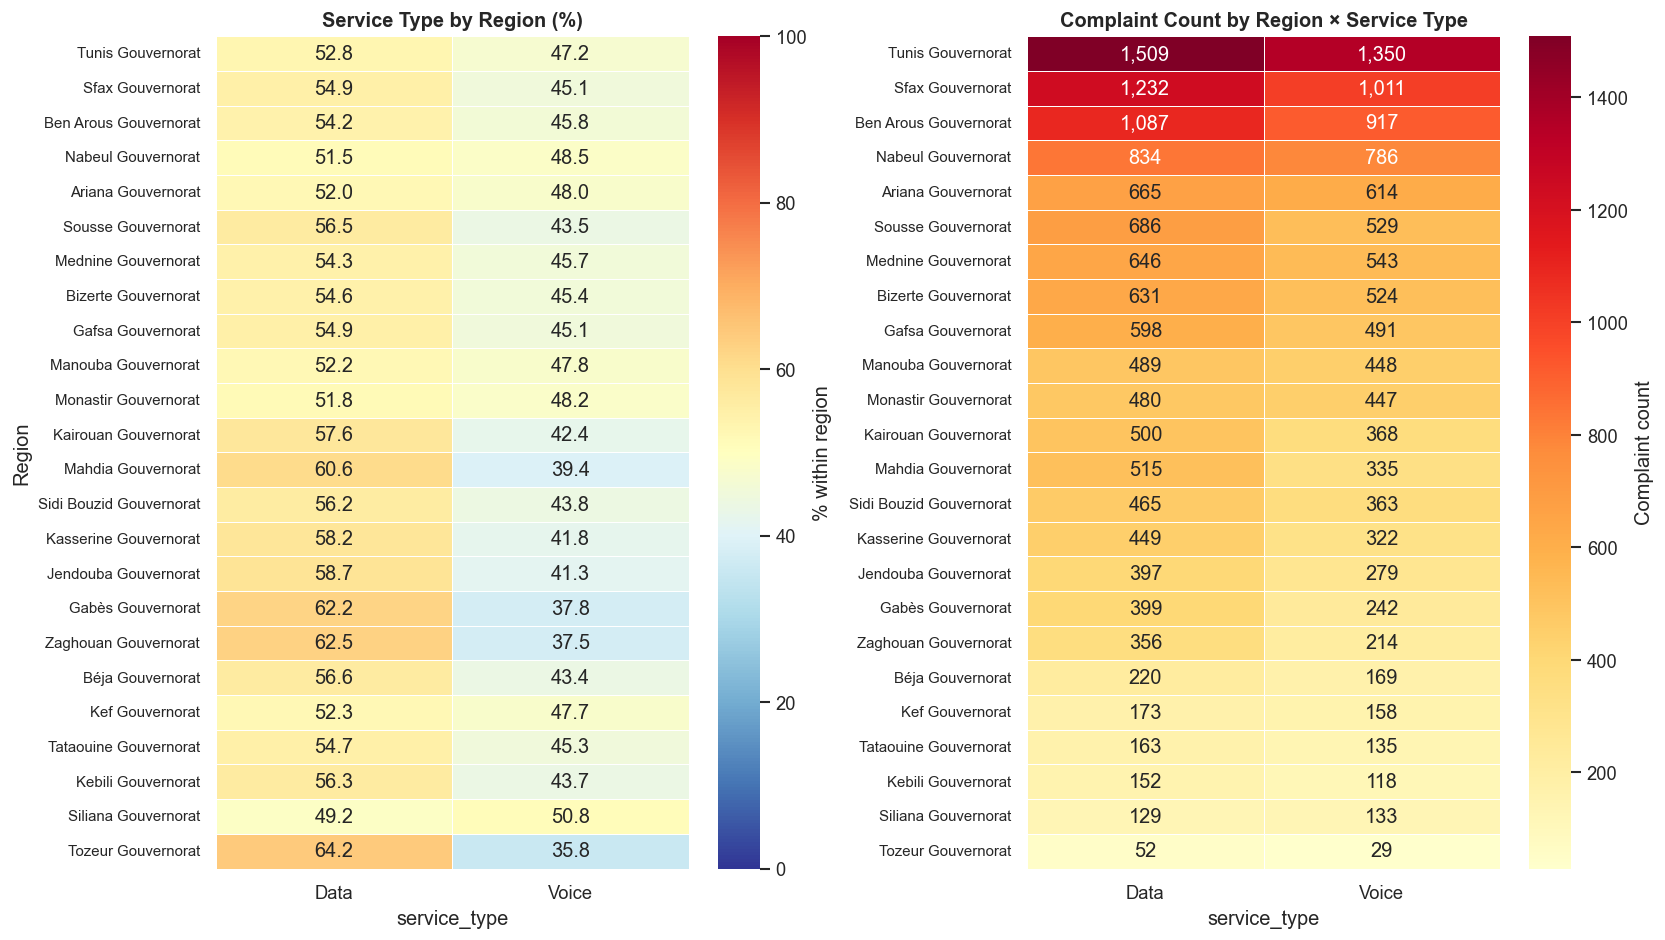

Top 3 regions:
  Tunis Gouvernorat          2,859  (11.1%)
  Sfax Gouvernorat           2,243  (8.7%)
  Ben Arous Gouvernorat      2,004  (7.8%)
Lowest 3 regions:
  Kebili Gouvernorat           270  (1.0%)
  Siliana Gouvernorat          262  (1.0%)
  Tozeur Gouvernorat            81  (0.3%)


In [9]:
# ── Cellule 9 — Geographic Distribution ───────────────────────────────────

# ── 1. Province + Top 20 Cities ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

if C_REGION in complaints.columns:
    prov = complaints[C_REGION].value_counts().sort_values()
    # Color intensity by volume
    norm   = plt.Normalize(prov.min(), prov.max())
    colors = plt.cm.Reds(norm(prov.values))

    bars = axes[0].barh(prov.index, prov.values,
                        color=colors, edgecolor='none', alpha=0.9)
    axes[0].bar_label(bars,
                      labels=[f'{v:,}' for v in prov.values],
                      padding=4, fontsize=8)
    axes[0].set_xlim(0, prov.max() * 1.20)
    axes[0].set_title('Complaints by Region (Gouvernorat)',
                      fontweight='bold')
    axes[0].set_xlabel('Number of Complaints')
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
else:
    axes[0].text(0.5, 0.5, f'"{C_REGION}" not found',
                 ha='center', va='center', transform=axes[0].transAxes)

if C_CITY in complaints.columns:
    city   = complaints[C_CITY].value_counts().head(20).sort_values()
    norm_c = plt.Normalize(city.min(), city.max())
    colors_c = plt.cm.Blues(norm_c(city.values))

    bars2 = axes[1].barh(city.index, city.values,
                         color=colors_c, edgecolor='none', alpha=0.9)
    axes[1].bar_label(bars2,
                      labels=[f'{v:,}' for v in city.values],
                      padding=4, fontsize=8)
    axes[1].set_xlim(0, city.max() * 1.20)
    axes[1].set_title('Top 20 Cities by Complaint Volume',
                      fontweight='bold')
    axes[1].set_xlabel('Number of Complaints')
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
else:
    axes[1].text(0.5, 0.5, f'"{C_CITY}" not found',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_geographic_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Region × Service Type heatmap ──────────────────────────────────────
if C_REGION in complaints.columns and C_TYPE in complaints.columns:
    # Sort regions by total complaints descending
    region_order = complaints[C_REGION].value_counts().index

    ct      = pd.crosstab(complaints[C_REGION], complaints[C_TYPE])
    ct      = ct.reindex(region_order)
    ct_pct  = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)

    fig, axes2 = plt.subplots(1, 2, figsize=(14, 8))

    # Heatmap % Data vs Voice
    sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='RdYlBu_r',
                linewidths=0.3, ax=axes2[0],
                cbar_kws={'label': '% within region'},
                vmin=0, vmax=100)
    axes2[0].set_title('Service Type by Region (%)',
                        fontweight='bold')
    axes2[0].set_ylabel('Region')
    axes2[0].tick_params(axis='y', rotation=0, labelsize=9)

    # Heatmap absolute counts
    sns.heatmap(ct, annot=True, fmt=',', cmap='YlOrRd',
                linewidths=0.3, ax=axes2[1],
                cbar_kws={'label': 'Complaint count'})
    axes2[1].set_title('Complaint Count by Region × Service Type',
                        fontweight='bold')
    axes2[1].set_ylabel('')
    axes2[1].tick_params(axis='y', rotation=0, labelsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_province_service_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
if C_REGION in complaints.columns:
    top3    = complaints[C_REGION].value_counts().head(3)
    bottom3 = complaints[C_REGION].value_counts().tail(3)
    print('Top 3 regions:')
    for r, cnt in top3.items():
        print(f'  {r:<25} {cnt:>6,}  ({cnt/len(complaints)*100:.1f}%)')
    print('Lowest 3 regions:')
    for r, cnt in bottom3.items():
        print(f'  {r:<25} {cnt:>6,}  ({cnt/len(complaints)*100:.1f}%)')

### 2.8 Customer Segments (Segment MSISDN CONCERN)

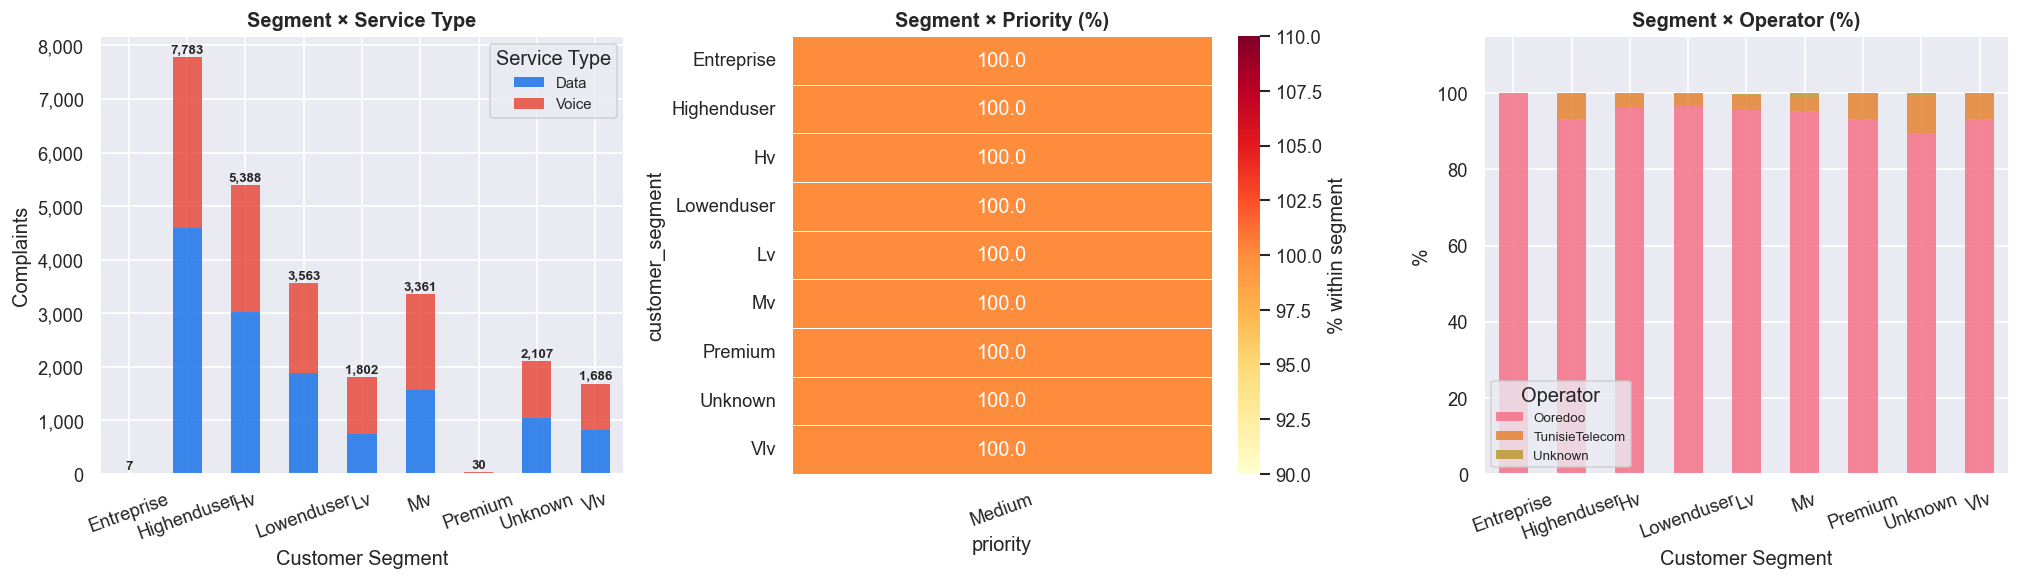

Customer segment breakdown:
  Highenduser                 7,783  (30.3%)
  Hv                          5,388  (20.9%)
  Lowenduser                  3,563  (13.8%)
  Mv                          3,361  (13.1%)
  Unknown                     2,107  (8.2%)
  Lv                          1,802  (7.0%)
  Vlv                         1,686  (6.6%)
  Premium                        30  (0.1%)
  Entreprise                      7  (0.0%)


In [10]:
# ── Cellule 10 — Customer Segments ────────────────────────────────────────

if C_SEGMENT not in complaints.columns:
    print(f'Column "{C_SEGMENT}" not found')
else:
    total = len(complaints)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── 1. Stacked bar — Segment × Service Type ────────────────────────
    pivot_svc = (complaints.groupby([C_SEGMENT, C_TYPE])
                            .size().unstack(fill_value=0)
                            if C_TYPE in complaints.columns
                            else complaints.groupby(C_SEGMENT)
                                           .size().to_frame('count'))

    pivot_svc.plot(kind='bar', ax=axes[0], stacked=True,
                   color=[C_DATA, C_VOICE][:len(pivot_svc.columns)],
                   edgecolor='none', alpha=0.85)
    # Add total labels on top of each bar
    totals = pivot_svc.sum(axis=1)
    for i, (idx, val) in enumerate(totals.items()):
        axes[0].text(i, val + total * 0.003,
                     f'{val:,}', ha='center', fontsize=8, fontweight='bold')
    axes[0].set_title('Segment × Service Type', fontweight='bold')
    axes[0].set_xlabel('Customer Segment')
    axes[0].set_ylabel('Complaints')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend(title='Service Type', fontsize=9)
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # ── 2. Segment × Priority heatmap ─────────────────────────────────
    if C_PRIORITY in complaints.columns:
        pivot_pri = (pd.crosstab(complaints[C_SEGMENT],
                                 complaints[C_PRIORITY],
                                 normalize='index')
                       .mul(100).round(1))
        # Order priority columns logically
        pri_order = [c for c in ['Critical','High','Medium','Low']
                     if c in pivot_pri.columns]
        pivot_pri = pivot_pri[pri_order]

        sns.heatmap(pivot_pri, annot=True, fmt='.1f',
                    cmap='YlOrRd', linewidths=0.3, ax=axes[1],
                    cbar_kws={'label': '% within segment'})
        axes[1].set_title('Segment × Priority (%)', fontweight='bold')
        axes[1].tick_params(axis='x', rotation=20)
        axes[1].tick_params(axis='y', rotation=0)
    else:
        axes[1].text(0.5, 0.5, 'priority column\nnot found',
                     ha='center', va='center',
                     transform=axes[1].transAxes)

    # ── 3. Segment × Operator ─────────────────────────────────────────
    if 'operator' in complaints.columns:
        pivot_op = (pd.crosstab(complaints[C_SEGMENT],
                                complaints['operator'],
                                normalize='index')
                      .mul(100).round(1))
        pivot_op.plot(kind='bar', ax=axes[2], stacked=True,
                      color=COLORS[:len(pivot_op.columns)],
                      edgecolor='none', alpha=0.85)
        axes[2].set_title('Segment × Operator (%)', fontweight='bold')
        axes[2].set_xlabel('Customer Segment')
        axes[2].set_ylabel('%')
        axes[2].tick_params(axis='x', rotation=20)
        axes[2].legend(title='Operator', fontsize=8)
        axes[2].set_ylim(0, 115)
    else:
        axes[2].text(0.5, 0.5, 'operator column\nnot found',
                     ha='center', va='center',
                     transform=axes[2].transAxes)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_customer_segment.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────
    print('Customer segment breakdown:')
    for seg, cnt in complaints[C_SEGMENT].value_counts().items():
        print(f'  {seg:<25} {cnt:>7,}  ({cnt/total*100:.1f}%)')

### 2.9 Hour × Day of Week Heatmap

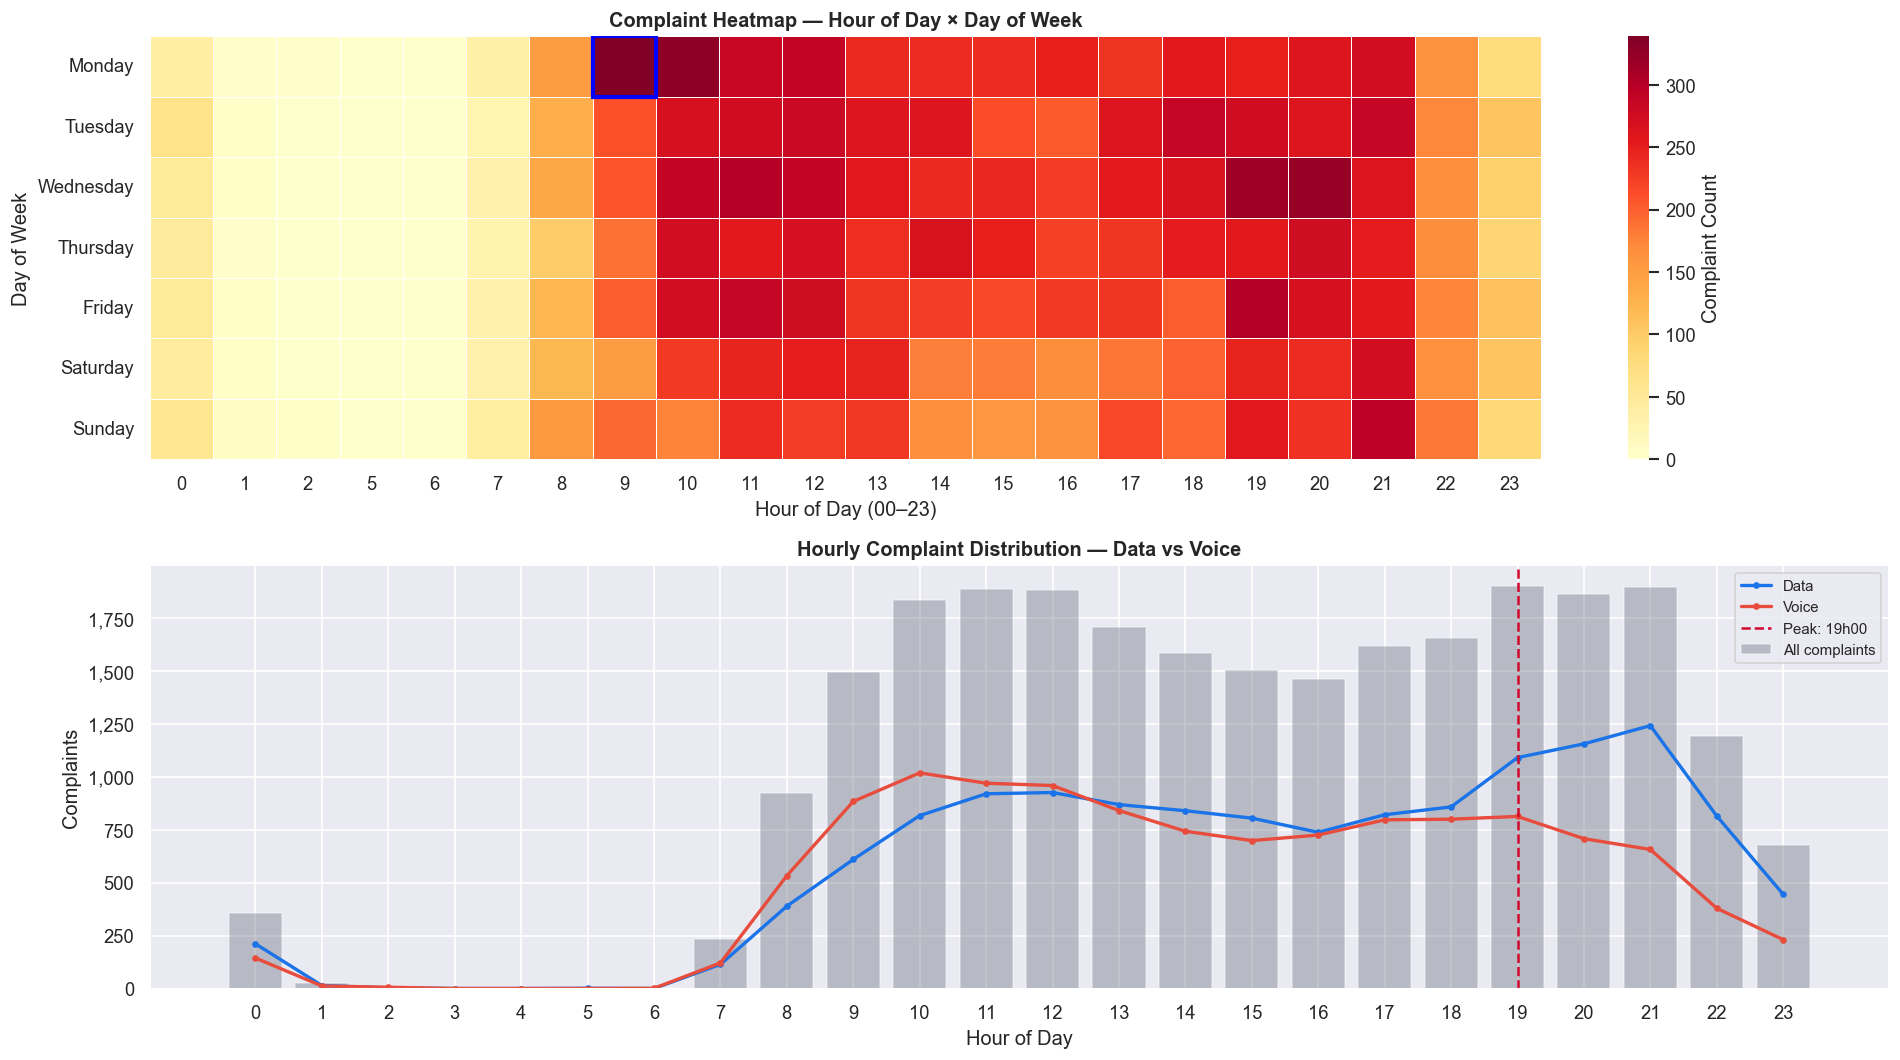

Peak hour    : 19:00  (1,904 complaints)
Lowest hour  : 05:00  (1 complaints)
Peak day     : Wednesday  (3,969 complaints)
Peak slot    : Monday at 07:00  (339 complaints)


In [11]:
# ── Cellule 11 — Temporal Patterns: Hour × Day Heatmap ────────────────────

if 'hour' not in complaints.columns or 'day_of_week' not in complaints.columns:
    print('hour/day_of_week not found — ensure timestamp was parsed correctly.')
else:
    DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday',
                 'Friday','Saturday','Sunday']

    pivot = (complaints.groupby(['day_of_week', 'hour'])
                       .size()
                       .unstack(fill_value=0)
                       .reindex([d for d in DOW_ORDER
                                  if d in complaints['day_of_week'].unique()]))

    fig, axes = plt.subplots(2, 1, figsize=(16, 9))

    # ── 1. Heatmap hour × day ──────────────────────────────────────────
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=axes[0],
                cbar_kws={'label': 'Complaint Count'},
                annot=False)

    # Annotate peak cell
    peak_val = pivot.values.max()
    peak_pos = np.unravel_index(pivot.values.argmax(), pivot.shape)
    axes[0].add_patch(plt.Rectangle(
        (peak_pos[1], peak_pos[0]), 1, 1,
        fill=False, edgecolor='blue', linewidth=2.5, label='Peak slot'
    ))
    axes[0].set_title('Complaint Heatmap — Hour of Day × Day of Week',
                      fontweight='bold')
    axes[0].set_xlabel('Hour of Day (00–23)')
    axes[0].set_ylabel('Day of Week')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].tick_params(axis='y', rotation=0)

    # ── 2. Hourly distribution + Data/Voice split ──────────────────────
    hourly = complaints.groupby('hour').size()
    axes[1].bar(hourly.index, hourly.values,
                color=C_NEUTRAL, alpha=0.4,
                label='All complaints', width=0.8)

    if C_TYPE in complaints.columns:
        for svc, color in [('Data', C_DATA), ('Voice', C_VOICE)]:
            svc_hourly = (complaints[complaints[C_TYPE] == svc]
                          .groupby('hour').size()
                          .reindex(range(24), fill_value=0))
            axes[1].plot(svc_hourly.index, svc_hourly.values,
                         linewidth=2, color=color,
                         marker='o', markersize=3, label=svc)

    # Mark peak hour
    peak_hour = int(hourly.idxmax())
    axes[1].axvline(peak_hour, color=HUAWEI_RED, linestyle='--',
                    linewidth=1.5, label=f'Peak: {peak_hour:02d}h00')
    axes[1].set_title('Hourly Complaint Distribution — Data vs Voice',
                      fontweight='bold')
    axes[1].set_xlabel('Hour of Day')
    axes[1].set_ylabel('Complaints')
    axes[1].set_xticks(range(24))
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGURES / 'eda_heatmap_hour_day.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary ────────────────────────────────────────────────────────
    peak_day  = complaints['day_of_week'].value_counts().idxmax()
    off_hour  = int(hourly.idxmin())
    print(f'Peak hour    : {peak_hour:02d}:00  ({hourly[peak_hour]:,} complaints)')
    print(f'Lowest hour  : {off_hour:02d}:00  ({hourly[off_hour]:,} complaints)')
    print(f'Peak day     : {peak_day}  ({complaints["day_of_week"].value_counts().max():,} complaints)')
    print(f'Peak slot    : {pivot.index[peak_pos[0]]} at {peak_pos[1]:02d}:00  ({peak_val:,} complaints)')

### 2.10 Sub-categories & Sub-sub-categories

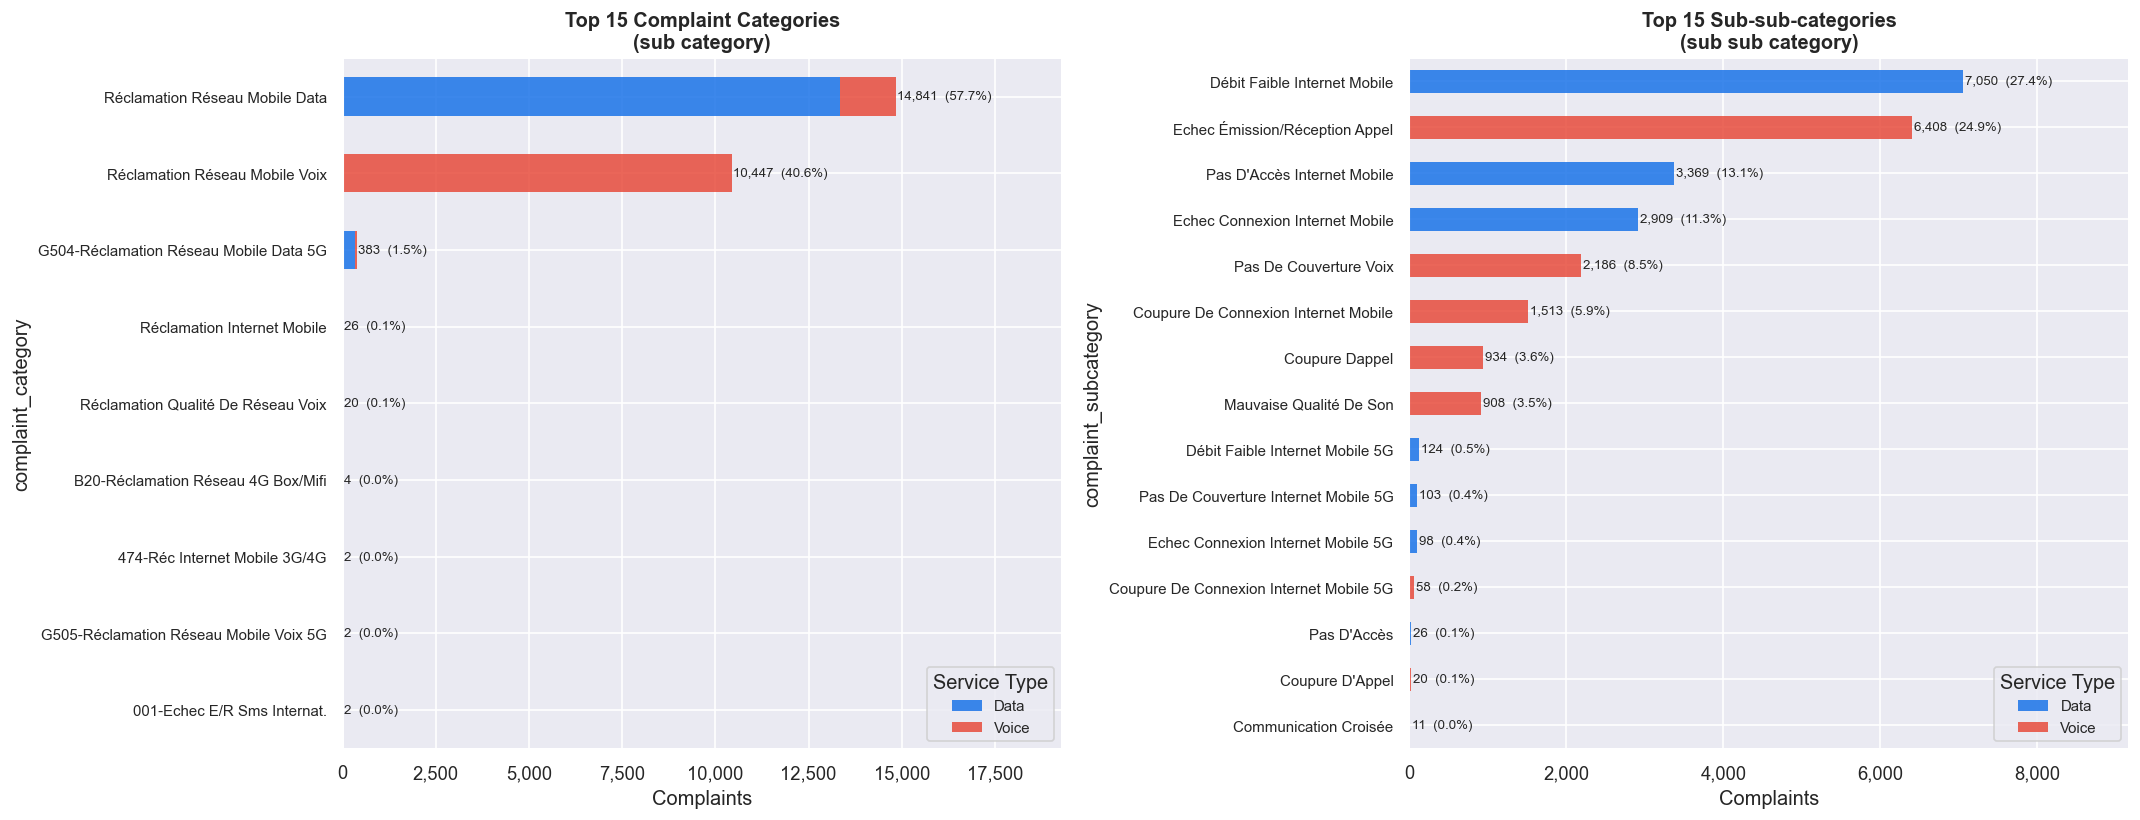

Top 5 complaint categories:
  Réclamation Réseau Mobile Data           14,841  (57.7%)
  Réclamation Réseau Mobile Voix           10,447  (40.6%)
  G504-Réclamation Réseau Mobile Data 5G      383  (1.5%)
  Réclamation Internet Mobile                  26  (0.1%)
  Réclamation Qualité De Réseau Voix           20  (0.1%)

Top 5 sub-sub-categories:
  Débit Faible Internet Mobile              7,050  (27.4%)
  Echec Émission/Réception Appel            6,408  (24.9%)
  Pas D'Accès Internet Mobile               3,369  (13.1%)
  Echec Connexion Internet Mobile           2,909  (11.3%)
  Pas De Couverture Voix                    2,186  (8.5%)


In [12]:
# ── Cellule 12 — Sub-categories & Sub-sub-categories ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── 1. Top 15 Sub-categories ──────────────────────────────────────────────
if C_CATEGORY in complaints.columns:
    top15 = (complaints[C_CATEGORY].value_counts()
                                    .head(15)
                                    .sort_values(ascending=True))
    total = len(complaints)

    if C_TYPE in complaints.columns:
        # Stacked bar Data / Voice
        pivot = (complaints[complaints[C_CATEGORY].isin(top15.index)]
                 .groupby([C_CATEGORY, C_TYPE])
                 .size().unstack(fill_value=0)
                 .reindex(top15.index))
        pivot.plot(kind='barh', ax=axes[0], stacked=True,
                   color=[C_DATA, C_VOICE][:len(pivot.columns)],
                   edgecolor='none', alpha=0.85)
        # Total labels
        row_totals = pivot.sum(axis=1)
        for i, val in enumerate(row_totals):
            axes[0].text(val + total * 0.001, i,
                         f'{val:,}  ({val/total*100:.1f}%)',
                         va='center', fontsize=8)
        axes[0].set_xlim(0, row_totals.max() * 1.30)
        axes[0].legend(title='Service Type', fontsize=9)
    else:
        bars = axes[0].barh(top15.index, top15.values,
                            color=COLORS[0], edgecolor='none', alpha=0.85)
        axes[0].bar_label(bars,
                          labels=[f'{v:,}  ({v/total*100:.1f}%)'
                                   for v in top15.values],
                          padding=4, fontsize=8)
        axes[0].set_xlim(0, top15.max() * 1.30)

    axes[0].set_title('Top 15 Complaint Categories\n(sub category)',
                      fontweight='bold')
    axes[0].set_xlabel('Complaints')
    axes[0].tick_params(axis='y', labelsize=9)
    axes[0].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
else:
    axes[0].text(0.5, 0.5, f'"{C_CATEGORY}" not found',
                 ha='center', va='center', transform=axes[0].transAxes)

# ── 2. Top 15 Sub-sub-categories ──────────────────────────────────────────
if C_SUBCAT in complaints.columns:
    top15_sub = (complaints[C_SUBCAT].value_counts()
                                      .head(15)
                                      .sort_values(ascending=True))

    if C_TYPE in complaints.columns:
        pivot2 = (complaints[complaints[C_SUBCAT].isin(top15_sub.index)]
                  .groupby([C_SUBCAT, C_TYPE])
                  .size().unstack(fill_value=0)
                  .reindex(top15_sub.index))
        pivot2.plot(kind='barh', ax=axes[1], stacked=True,
                    color=[C_DATA, C_VOICE][:len(pivot2.columns)],
                    edgecolor='none', alpha=0.85)
        row_totals2 = pivot2.sum(axis=1)
        for i, val in enumerate(row_totals2):
            axes[1].text(val + total * 0.001, i,
                         f'{val:,}  ({val/total*100:.1f}%)',
                         va='center', fontsize=8)
        axes[1].set_xlim(0, row_totals2.max() * 1.30)
        axes[1].legend(title='Service Type', fontsize=9)
    else:
        bars2 = axes[1].barh(top15_sub.index, top15_sub.values,
                             color=COLORS[2], edgecolor='none', alpha=0.85)
        axes[1].bar_label(bars2,
                          labels=[f'{v:,}' for v in top15_sub.values],
                          padding=4, fontsize=8)
        axes[1].set_xlim(0, top15_sub.max() * 1.20)

    axes[1].set_title('Top 15 Sub-sub-categories\n(sub sub category)',
                      fontweight='bold')
    axes[1].set_xlabel('Complaints')
    axes[1].tick_params(axis='y', labelsize=9)
    axes[1].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
else:
    axes[1].text(0.5, 0.5, f'"{C_SUBCAT}" not found',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_subcategory_top.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
if C_CATEGORY in complaints.columns:
    print('Top 5 complaint categories:')
    for cat, cnt in complaints[C_CATEGORY].value_counts().head(5).items():
        print(f'  {cat:<40} {cnt:>6,}  ({cnt/total*100:.1f}%)')

if C_SUBCAT in complaints.columns:
    print('\nTop 5 sub-sub-categories:')
    for cat, cnt in complaints[C_SUBCAT].value_counts().head(5).items():
        print(f'  {cat:<40} {cnt:>6,}  ({cnt/total*100:.1f}%)')

## 3. KPI

  dataCollectionist — SNAPSHOT OVERVIEW (2026-03-13)
  Total subscribers    : 4,898
  Snapshot date        : 2026-03-13  (single day)
  Total columns        : 129
  Real KPI columns     : 67
  Traffic columns      : 31
  Gouvernorats (L2)    : 24
  Sites (LAYER3)       : 255
  Site names           : 2631
  Device brands        : 90


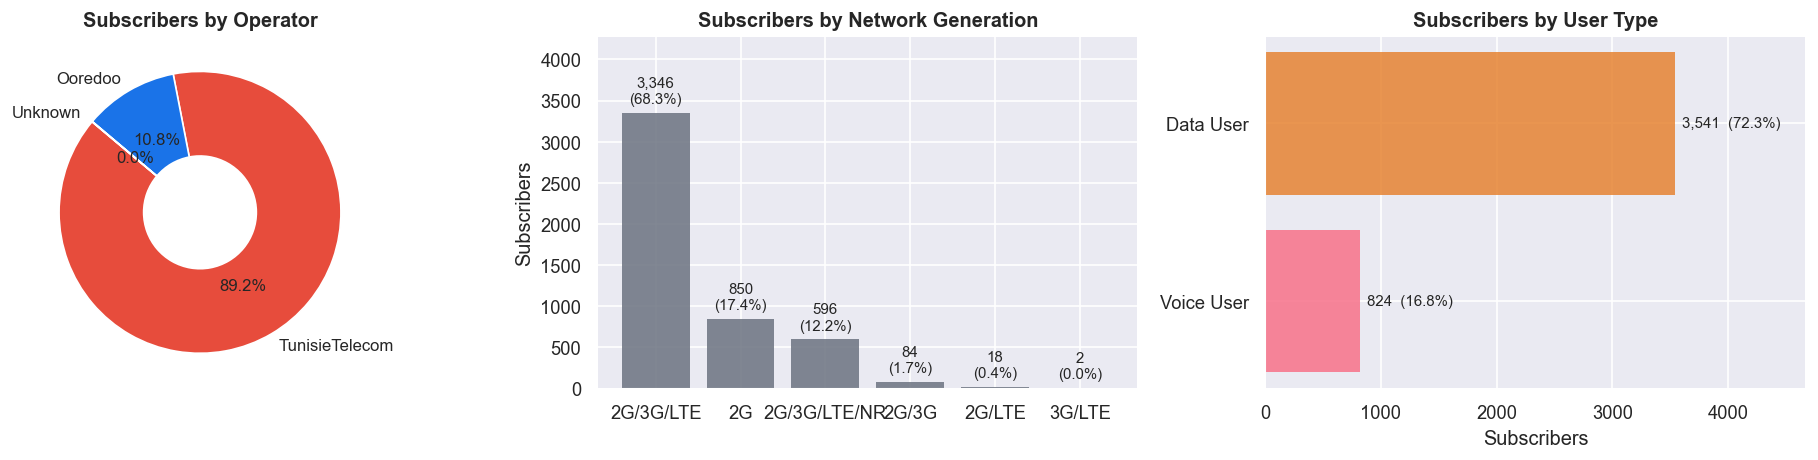

Operator split:
  TunisieTelecom          4,367  (89.2%)
  Ooredoo                   529  (10.8%)
  Unknown                     2  (0.0%)

Generation split:
  2G/3G/LTE   3,346  (68.3%)
  2G            850  (17.4%)
  2G/3G/LTE/NR    596  (12.2%)
  2G/3G          84  (1.7%)
  2G/LTE         18  (0.4%)
  3G/LTE          2  (0.0%)

Gouvernorats couverts:
  Tunis                            634  (12.9%)
  Sfax                             356  (7.3%)
  Sousse                           346  (7.1%)
  Ben Arous                        311  (6.3%)
  Kasserine                        309  (6.3%)
  Kairouan                         296  (6.0%)
  Monastir                         256  (5.2%)
  Sidi_Bouzid                      251  (5.1%)
  Nabeul                           246  (5.0%)
  Bizerte                          232  (4.7%)
  Siliana                          190  (3.9%)
  Manouba                          167  (3.4%)
  Mahdia                           156  (3.2%)
  Ariana                          

In [13]:
# ── Cellule 13 — dataCollectionist : Vue d'ensemble ───────────────────────

# ── Fix region : LAYER2NAME = gouvernorat ─────────────────────────────────
dc['region'] = (dc['LAYER2NAME'].astype(str)
                .str.strip().str.title()
                .replace('Nan', pd.NA))

# ── Column categorisation (définies ici, réutilisées dans cells 14-19) ────
COLS_IDENTITY = {
    'TIMEE', 'imsi', 'msisdn', 'MSISDN', 'mcc', 'mnc',
    'tac', 'model', 'tertype', 'brand', 'sim_capability',
    'usim_flag', 'volte_flag', 'apn', 'home_cell', 'home_site',
    'SITE_NAME', 'LAYER1NAME', 'LAYER2NAME', 'LAYER3NAME',
    'RAN_NE_VENDOR', 'longitude', 'latitude',
    'usertype', 'User_Class', 'mobility_class',
    'number_of_regions', 'generation', 'roaming_direction',
    'operator', 'reserved_field1', 'reserved_field2',
    'reserved_field3', 'reserved_field4', 'reserved_field5',
}
COLS_TRAFFIC = [c for c in [
    'traffic_2g', 'traffic_3g', 'traffic_4g', 'duration',
    'voice_onlinetime_3g', 'voice_onlinetime_2g', 'Dou_Total',
    'game_traffic', 'Streaming_traffic', 'IM_traffic',
    'Web_Browsing_traffic', 'Other_traffic', 'VoIP_traffic',
    'SMS_traffic', 'TikTok_traffic', 'Instagram_traffic',
    'Facebook_traffic', 'Facebook_Messenger_traffic',
    'HTTPS_traffic', 'QUIC_IETF_traffic', 'YouTube_traffic',
    'Google_Common_traffic', 'WhatsApp_traffic',
    'GoogleSearch_traffic', 'FreeFire_traffic', 'PUBG_traffic',
    'night_traffic', 'day_traffic', 'late_night_traffic',
    'Speedtest_traffic', 'nPerf_traffic',
] if c in dc.columns]

COLS_KPI_VIDEO = [c for c in [
    'video_streaming_download_throughput', 'Video_xkb_start_delay',
    'Video_Streaming_Start_Success_Rate', 'Video_Streaming_Start_Delay',
    'Video_Streaming_Stall_Frequency',
] if c in dc.columns]

COLS_KPI_WEB = [c for c in [
    'Page_Response_Success_Rate', 'Page_Response_Delay',
    'Page_Browsing_Success_Rate', 'Page_Browsing_Delay',
    'Page_Download_Throughput',
] if c in dc.columns]

COLS_KPI_VOIP = [c for c in [
    'VoIP_Voice_Uplink_Throughput', 'VoIP_Voice_Downlink_Throughput',
    'VoIP_Video_Uplink_Throughput', 'VoIP_Video_Downlink_Throughput',
    'IM_interactive_delay',
] if c in dc.columns]

COLS_KPI_FILE = [c for c in [
    'File_Sharing_Response_Delay', 'File_Sharing_Upload_Throughput',
    'File_Sharing_Download_Throughput', 'Multimedia_Response_Delay',
    'Multimedia_Uplink_Throughput', 'Multimedia_Downlink_Throughput',
] if c in dc.columns]

COLS_KPI_NETWORK = [c for c in [
    'e2e_delay_ms', 'client_rtt_ms', 'server_rtt_ms',
    'Client_Packet_Loss_Rate', 'SERVER_Packet_Loss_Rate',
    'TCP_connection_sr', 'SYN_ACK_ACK_delay', 'SYN_SYN_ACK_delay',
    'Https_Handshake_Success_Rate', 'dns_delay', 'DNS_SR',
    'UDP_Uplink_Packet_Intervals_ms', 'UDP_Downlink_Packet_Intervals_ms',
    'UDP_Uplink_Jitter', 'UDP_Downlink_Jitter',
    'QUIC_Uplink_Packet_Loss_Rate', 'QUIC_Downlink_Packet_Loss_Rate',
    'QUIC_Uplink_Out_of_Order_Rate', 'QUIC_Downlink_Out_of_Order_Rate',
] if c in dc.columns]

COLS_KPI_SIGNALLING = [c for c in [
    'E_RAB_SR', 'S1_MME_SR', 'S1_MME_Auth_SR',
    'S1_MME_DF_EPS_Bearer_Context_Activation_SR',
    'Iu_Attach_SR', 'IU_PDP_Context_Procedure_Activation_SR',
    'IU_Paging_SR', 'IU_Auth_ciphering_SR',
    'Gb_Attach_SR', 'GB_PDP_Context_Procedure_Activation_SR',
    'GB_Paging_SR', 'GB_Auth_ciphering_SR',
    'S6a_Auth_Info_Obtai_SR', 'S6a_update_location_SR',
    'CCR_I', 'CCR_U', 'CCR_I_GX', 'CCR_U_GX',
    'Gr_Send_Authentication_Information_SR', 'Gr_Update_Location_SR',
    'S5_S8_Default_Bearer_Creation_SR', 'S3S10Context_SR',
    'GnGpCreate_PDP_Context_Procedure_SR',
    'SGs_Location_Update_Success_Rate', 'SGs_Paging_Success_Rate',
    'SGs_SMS_Origination_Success_Rate', 'SGs_SMS_Termination_Success_Rate',
] if c in dc.columns]

COLS_KPI_ALL = (COLS_KPI_VIDEO + COLS_KPI_WEB + COLS_KPI_VOIP +
                COLS_KPI_FILE + COLS_KPI_NETWORK + COLS_KPI_SIGNALLING)

# ── Overview ───────────────────────────────────────────────────────────────
print('=' * 58)
print('  dataCollectionist — SNAPSHOT OVERVIEW (2026-03-13)')
print('=' * 58)
print(f'  Total subscribers    : {len(dc):,}')
print(f'  Snapshot date        : 2026-03-13  (single day)')
print(f'  Total columns        : {dc.shape[1]}')
print(f'  Real KPI columns     : {len(COLS_KPI_ALL)}')
print(f'  Traffic columns      : {len(COLS_TRAFFIC)}')
print(f'  Gouvernorats (L2)    : {dc["region"].nunique()}')
print(f'  Sites (LAYER3)       : {dc["LAYER3NAME"].nunique()
      if "LAYER3NAME" in dc.columns else "N/A"}')
print(f'  Site names           : {dc["SITE_NAME"].nunique()
      if "SITE_NAME" in dc.columns else "N/A"}')
print(f'  Device brands        : {dc["brand"].nunique()
      if "brand" in dc.columns else "N/A"}')
print('=' * 58)

# ── 3 charts : Operator · Generation · User Type ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Operator donut
if 'operator' in dc.columns:
    op_counts = dc['operator'].value_counts()
    op_colors = [C_VOICE, C_DATA, C_NEUTRAL][:len(op_counts)]
    axes[0].pie(op_counts, labels=op_counts.index,
                autopct='%1.1f%%', colors=op_colors,
                startangle=140, wedgeprops=dict(width=0.6),
                textprops=dict(fontsize=10))
    axes[0].set_title('Subscribers by Operator', fontweight='bold')

# 2. Network generation bar
if 'generation' in dc.columns:
    gen_counts = dc['generation'].value_counts()
    gen_colors = {'4G': C_DATA, '3G': COLORS[3],
                  '2G': C_NEUTRAL, '5G': COLORS[1]}
    colors_gen = [gen_colors.get(str(g), C_NEUTRAL)
                  for g in gen_counts.index]
    bars = axes[1].bar(gen_counts.index.astype(str), gen_counts.values,
                       color=colors_gen, edgecolor='none', alpha=0.85)
    axes[1].bar_label(bars,
                      labels=[f'{v:,}\n({v/len(dc)*100:.1f}%)'
                               for v in gen_counts.values],
                      padding=4, fontsize=9)
    axes[1].set_title('Subscribers by Network Generation',
                      fontweight='bold')
    axes[1].set_ylabel('Subscribers')
    axes[1].set_ylim(0, gen_counts.max() * 1.28)

# 3. User type barh
if 'usertype' in dc.columns:
    ut_counts = dc['usertype'].value_counts().sort_values()
    bars2 = axes[2].barh(ut_counts.index.astype(str), ut_counts.values,
                         color=COLORS[:len(ut_counts)],
                         edgecolor='none', alpha=0.85)
    axes[2].bar_label(bars2,
                      labels=[f'{v:,}  ({v/len(dc)*100:.1f}%)'
                               for v in ut_counts.values],
                      padding=4, fontsize=9)
    axes[2].set_xlim(0, ut_counts.max() * 1.32)
    axes[2].set_title('Subscribers by User Type', fontweight='bold')
    axes[2].set_xlabel('Subscribers')

plt.tight_layout()
plt.savefig(FIGURES / 'eda_dc_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print('Operator split:')
for op, cnt in dc['operator'].value_counts().items():
    print(f'  {op:<22} {cnt:>6,}  ({cnt/len(dc)*100:.1f}%)')

if 'generation' in dc.columns:
    print('\nGeneration split:')
    for gen, cnt in dc['generation'].value_counts().items():
        print(f'  {str(gen):<10} {cnt:>6,}  ({cnt/len(dc)*100:.1f}%)')

print('\nGouvernorats couverts:')
for reg, cnt in dc['region'].value_counts().items():
    print(f'  {reg:<30} {cnt:>5,}  ({cnt/len(dc)*100:.1f}%)')

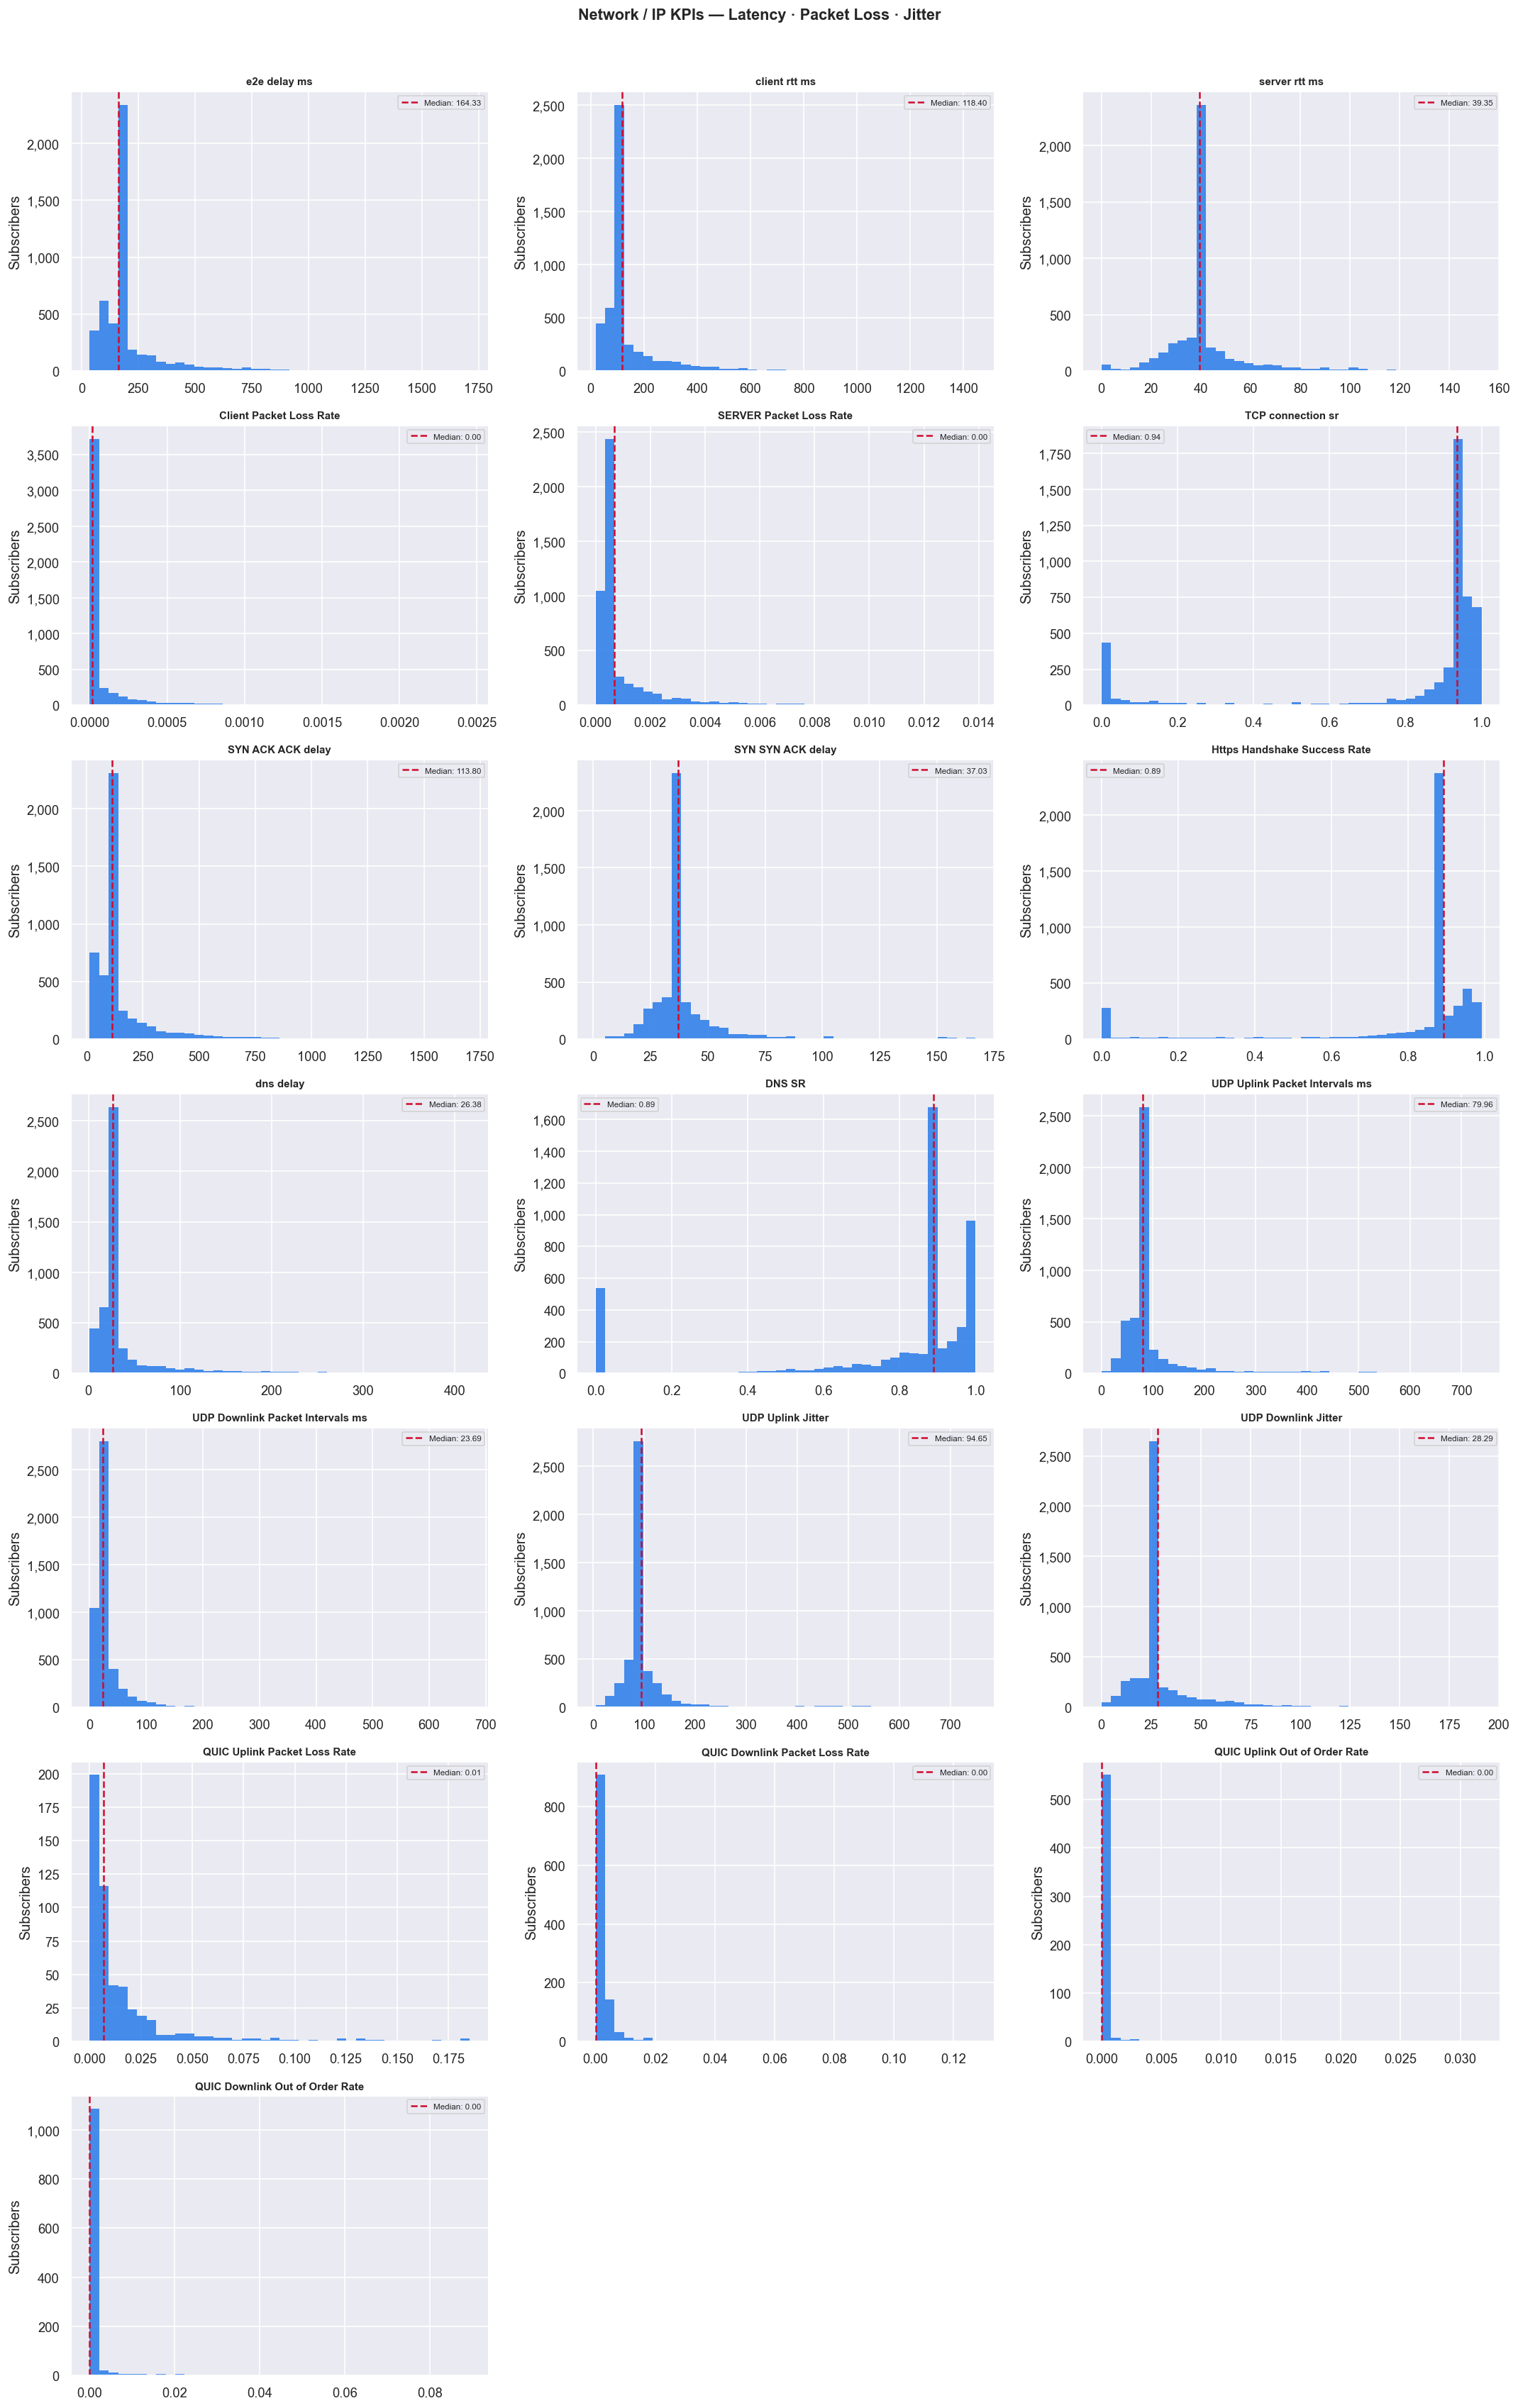


Network / IP KPIs — Latency · Packet Loss · Jitter — descriptive stats:
  Column                                               Median     Mean   Nulls%        P90
  -------------------------------------------------- -------- -------- -------- ----------
  e2e_delay_ms                                         164.33   255.19     0.0%     439.26
  client_rtt_ms                                        118.40   191.33     0.0%     340.85
  server_rtt_ms                                         39.35    45.14     0.0%      65.70
  Client_Packet_Loss_Rate                                0.00     0.00     0.0%       0.00
  SERVER_Packet_Loss_Rate                                0.00     0.00     0.0%       0.00
  TCP_connection_sr                                      0.94     0.80     0.0%       0.98
  SYN_ACK_ACK_delay                                    113.80   210.44     0.0%     374.78
  SYN_SYN_ACK_delay                                     37.03    42.92     0.0%      56.67
  Https_Handshake

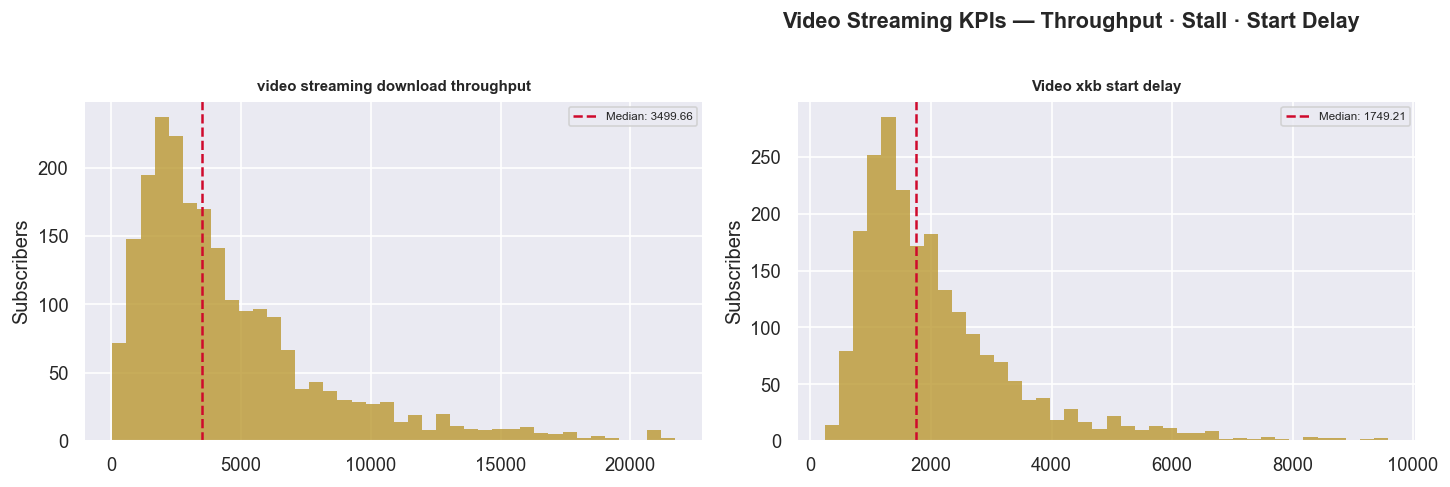


Video Streaming KPIs — Throughput · Stall · Start Delay — descriptive stats:
  Column                                               Median     Mean   Nulls%        P90
  -------------------------------------------------- -------- -------- -------- ----------
  video_streaming_download_throughput                 3499.66  4822.08    54.6%    9955.63
  Video_xkb_start_delay                               1749.21  2249.04    54.6%    3949.39


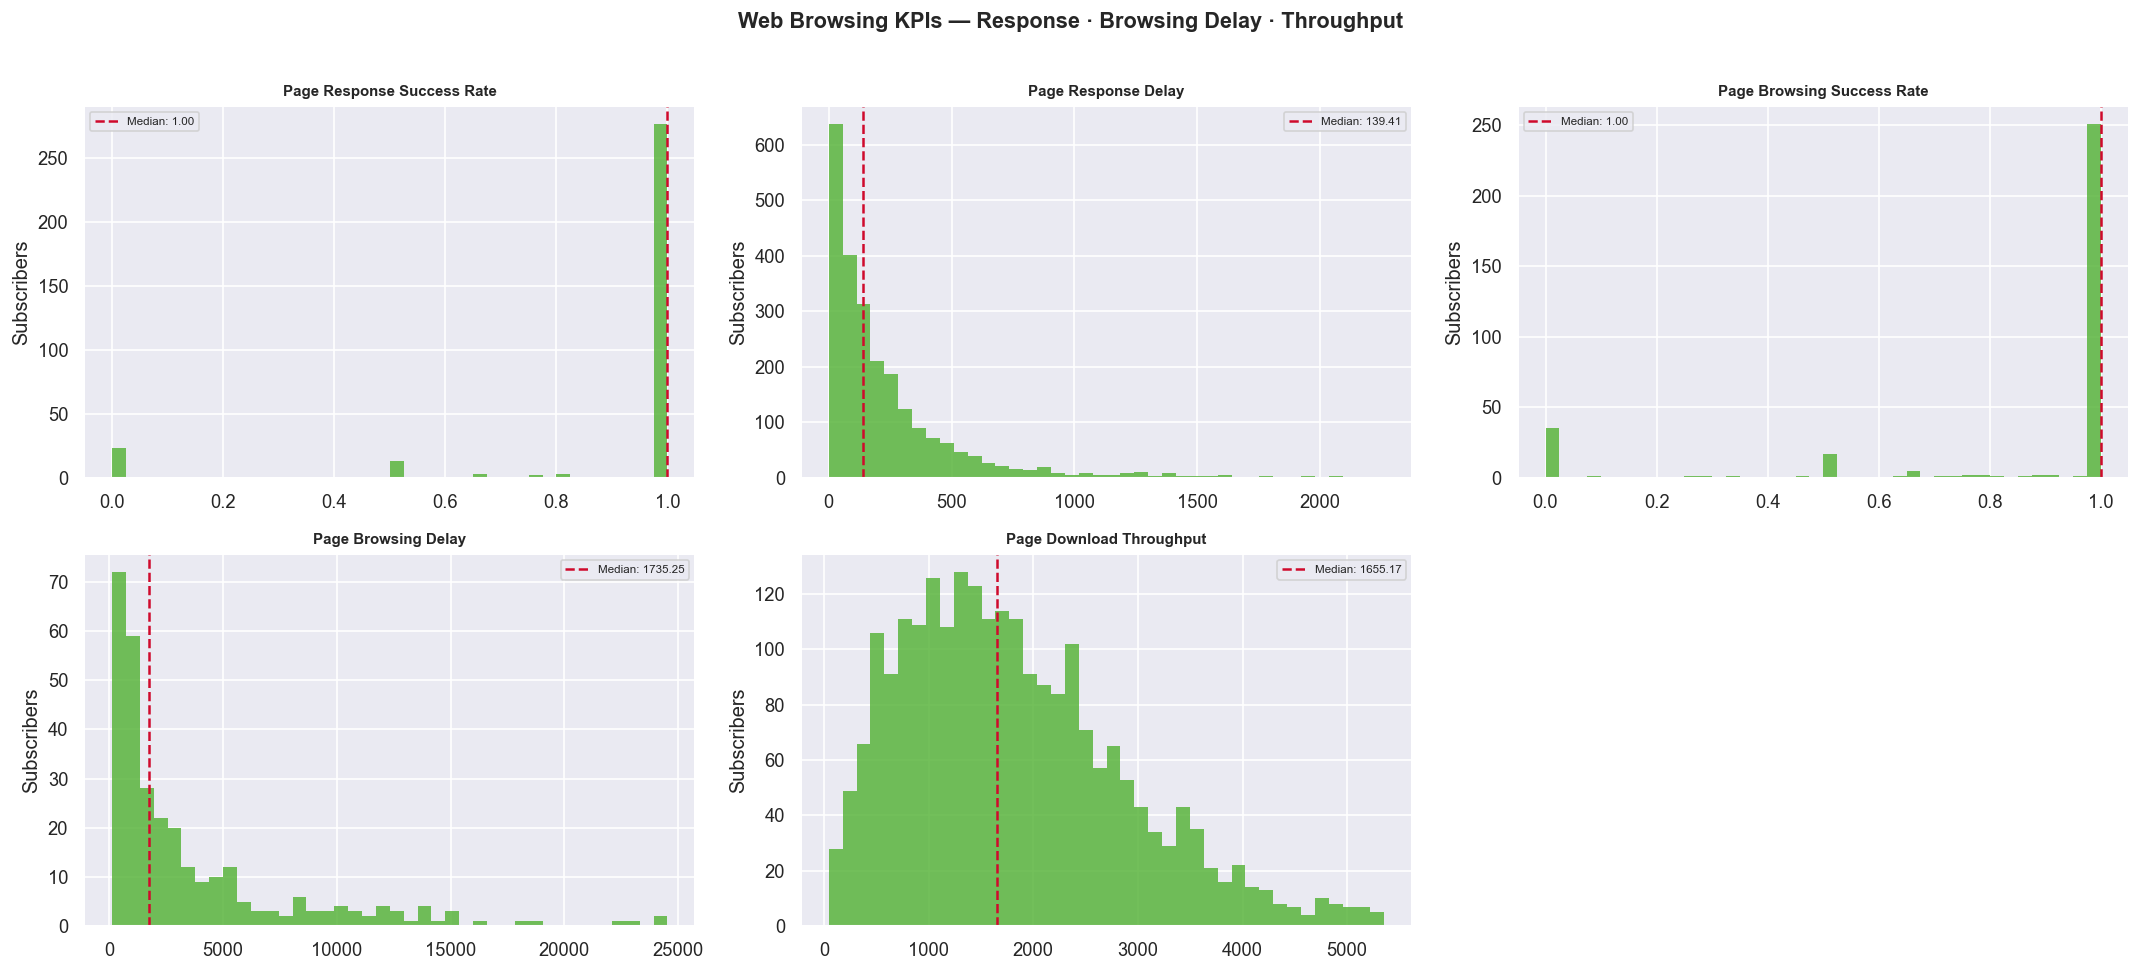


Web Browsing KPIs — Response · Browsing Delay · Throughput — descriptive stats:
  Column                                               Median     Mean   Nulls%        P90
  -------------------------------------------------- -------- -------- -------- ----------
  Page_Response_Success_Rate                             1.00     0.89    93.3%       1.00
  Page_Response_Delay                                  139.41   271.70    50.9%     587.87
  Page_Browsing_Success_Rate                             1.00     0.84    93.3%       1.00
  Page_Browsing_Delay                                 1735.25  4030.76    93.8%   10553.59
  Page_Download_Throughput                            1655.17  1856.69    52.2%    3391.53


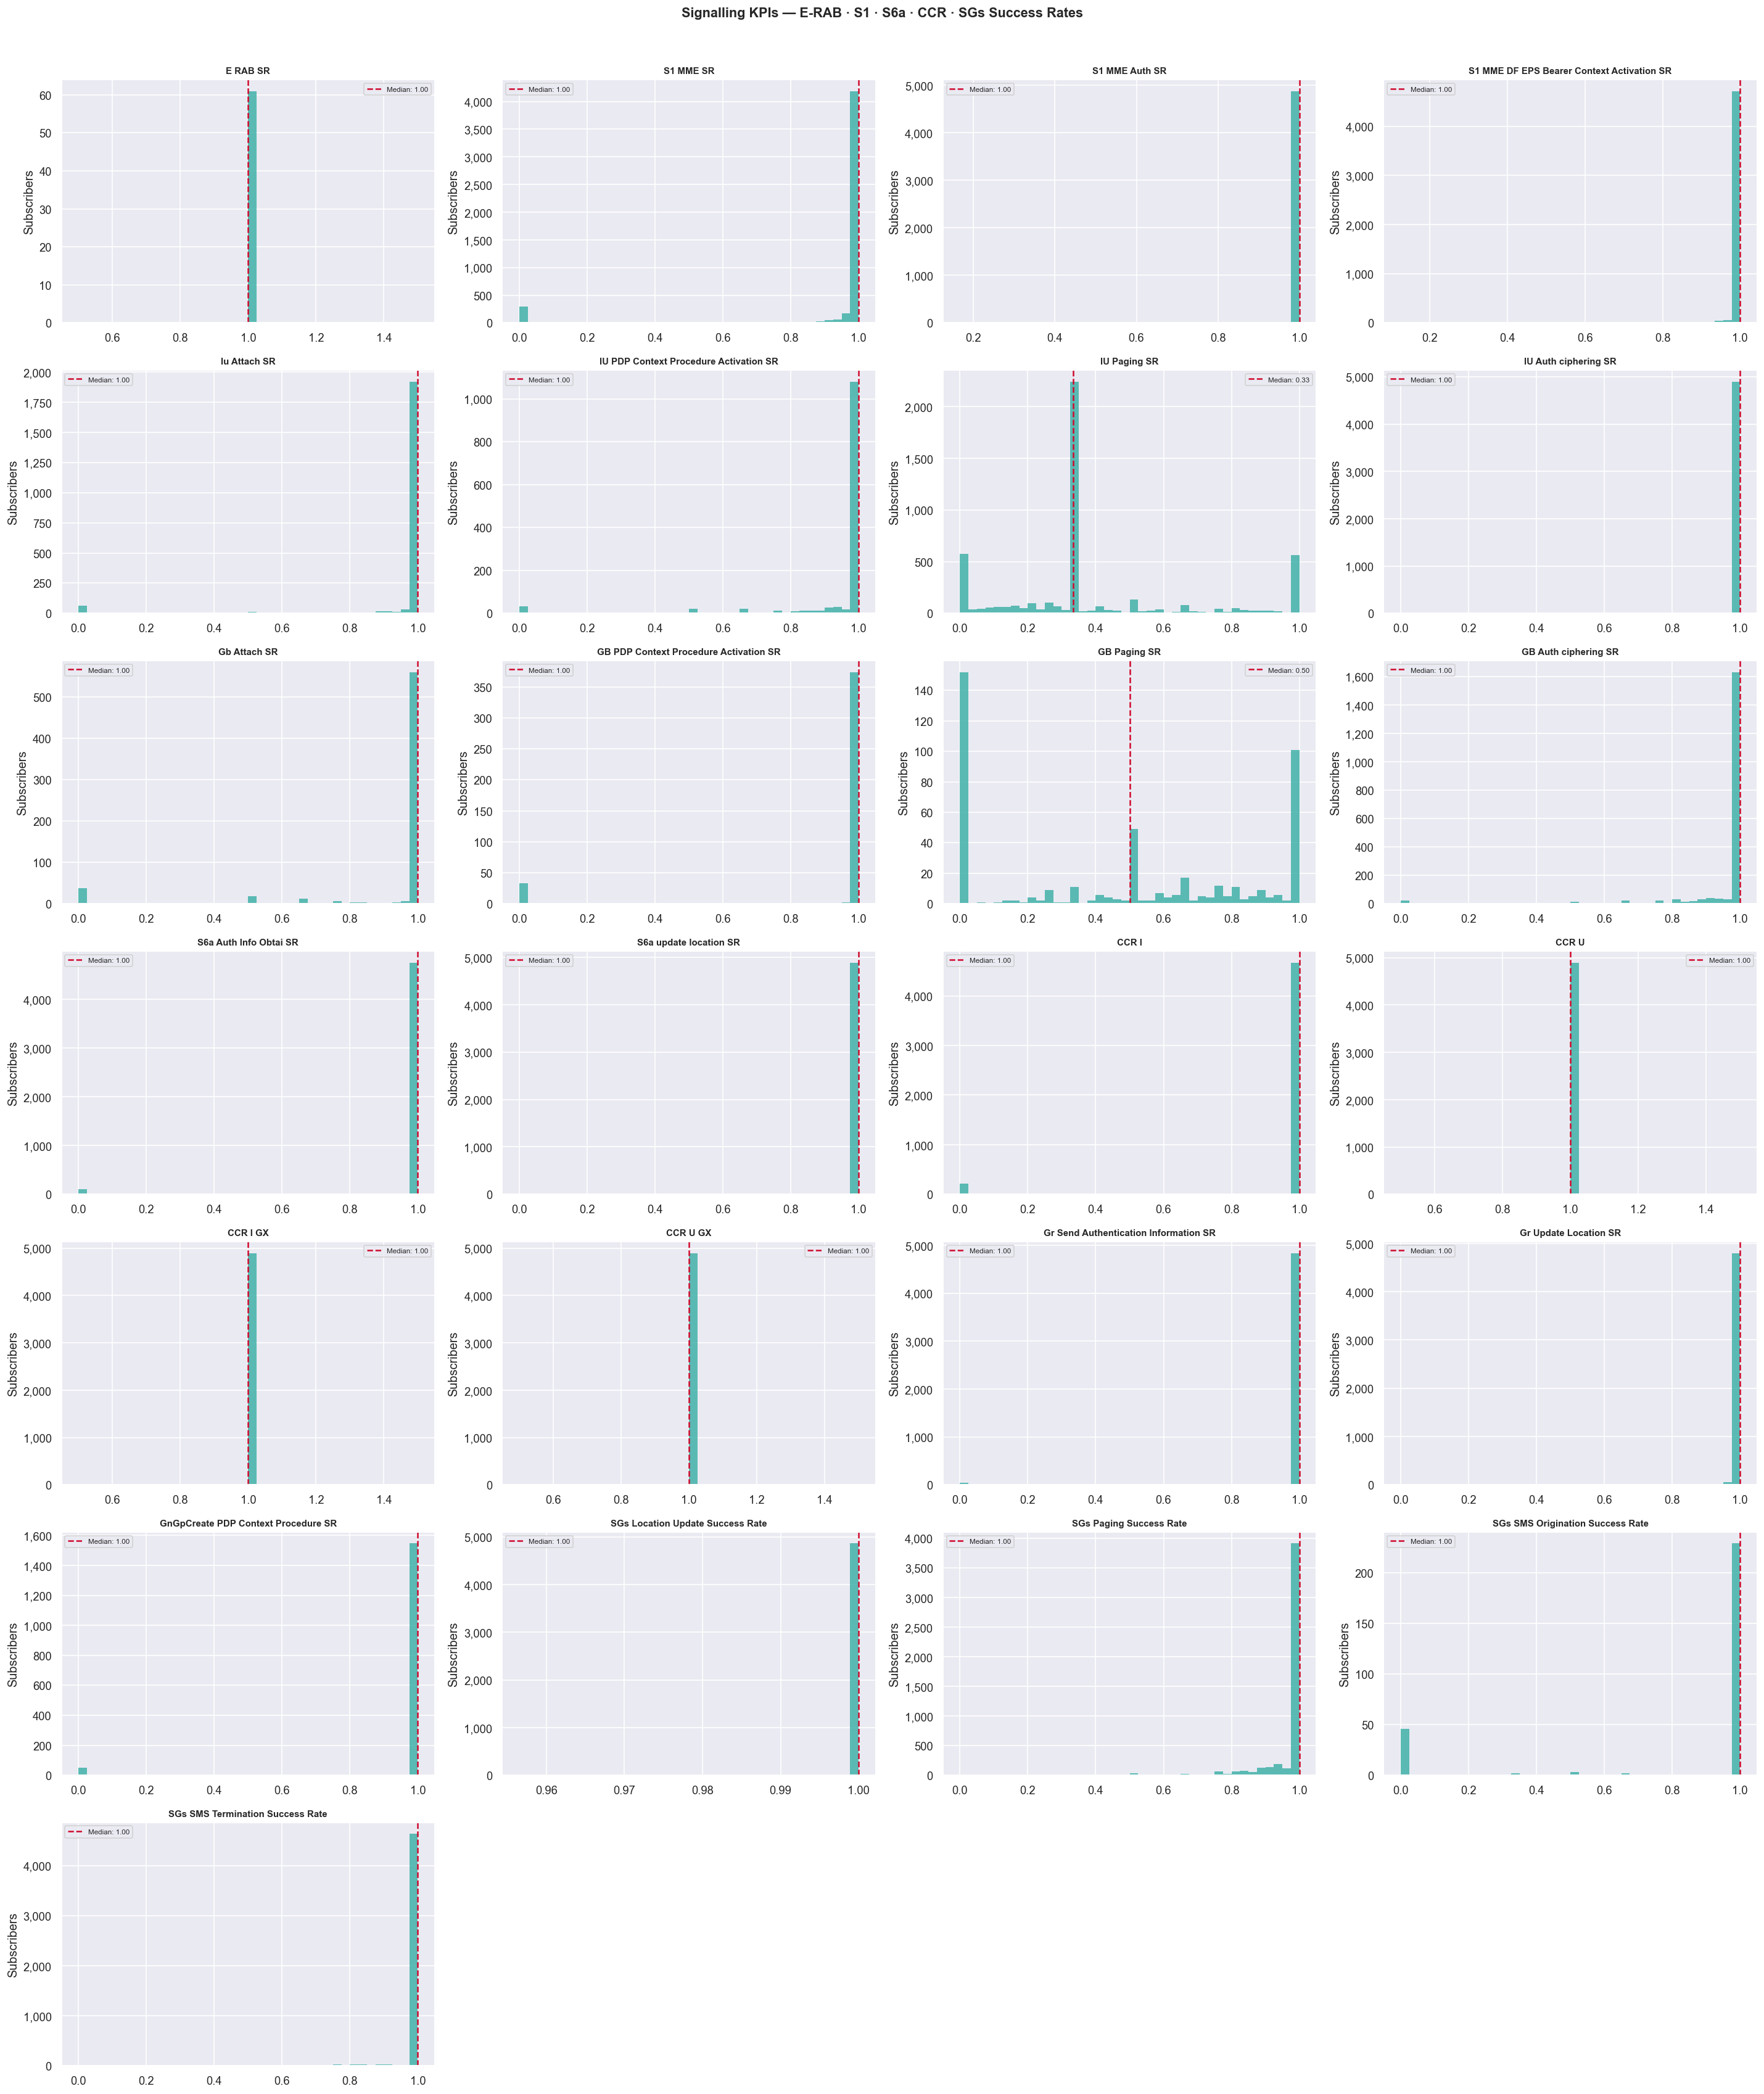


Signalling KPIs — E-RAB · S1 · S6a · CCR · SGs Success Rates — descriptive stats:
  Column                                               Median     Mean   Nulls%        P90
  -------------------------------------------------- -------- -------- -------- ----------
  E_RAB_SR                                               1.00     1.00    98.8%       1.00
  S1_MME_SR                                              1.00     0.93     0.0%       1.00
  S1_MME_Auth_SR                                         1.00     1.00     0.0%       1.00
  S1_MME_DF_EPS_Bearer_Context_Activation_SR             1.00     1.00     0.0%       1.00
  Iu_Attach_SR                                           1.00     0.96    56.6%       1.00
  IU_PDP_Context_Procedure_Activation_SR                 1.00     0.94    73.0%       1.00
  IU_Paging_SR                                           0.33     0.39     0.0%       1.00
  IU_Auth_ciphering_SR                                   1.00     1.00     0.0%       1.00
  Gb_At

In [14]:
# ── Cellule 14 — KPI Distributions ────────────────────────────────────────
# Histogrammes des 4 groupes KPI les plus importants pour la thèse :
#   1. Network/IP  (latence, packet loss, RTT)
#   2. Video       (débit streaming, stall, start delay)
#   3. Web         (page load, response delay)
#   4. Signalling  (E_RAB_SR, S1_MME_SR, DNS_SR...)

def plot_kpi_group(cols, title, fig_name, n_cols=3, color=C_DATA):
    """Plot histogram grid for a list of KPI columns."""
    present = [c for c in cols if c in dc.columns
               and dc[c].notna().sum() > 10]
    if not present:
        print(f'  No data for {title}')
        return

    n_rows = (len(present) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, col in enumerate(present):
        data = dc[col].dropna()
        q99  = data.quantile(0.99)
        data_clipped = data[data <= q99]   # remove extreme outliers

        axes[i].hist(data_clipped, bins=40,
                     color=color, alpha=0.8, edgecolor='none')
        axes[i].axvline(data.median(), color=HUAWEI_RED,
                        linestyle='--', linewidth=1.5,
                        label=f'Median: {data.median():.2f}')
        axes[i].set_title(col.replace('_', ' '), fontsize=9,
                          fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Subscribers')
        axes[i].legend(fontsize=7)
        axes[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

    # Hide empty subplots
    for j in range(len(present), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES / fig_name, dpi=150, bbox_inches='tight')
    plt.show()

    # Quick stats
    print(f'\n{title} — descriptive stats:')
    print(f'  {"Column":<50} {"Median":>8} {"Mean":>8} '
          f'{"Nulls%":>8} {"P90":>10}')
    print(f'  {"-"*50} {"-"*8} {"-"*8} {"-"*8} {"-"*10}')
    for col in present:
        s       = dc[col].dropna()
        null_p  = dc[col].isnull().mean() * 100
        print(f'  {col:<50} {s.median():>8.2f} {s.mean():>8.2f} '
              f'{null_p:>7.1f}% {s.quantile(0.9):>10.2f}')

# ── 1. Network / IP KPIs ──────────────────────────────────────────────────
plot_kpi_group(
    COLS_KPI_NETWORK,
    'Network / IP KPIs — Latency · Packet Loss · Jitter',
    'eda_dc_kpi_network.png',
    color=C_DATA,
)

# ── 2. Video Streaming KPIs ───────────────────────────────────────────────
plot_kpi_group(
    COLS_KPI_VIDEO,
    'Video Streaming KPIs — Throughput · Stall · Start Delay',
    'eda_dc_kpi_video.png',
    n_cols=3,
    color=COLORS[2],
)

# ── 3. Web Browsing KPIs ──────────────────────────────────────────────────
plot_kpi_group(
    COLS_KPI_WEB,
    'Web Browsing KPIs — Response · Browsing Delay · Throughput',
    'eda_dc_kpi_web.png',
    n_cols=3,
    color=COLORS[4],
)

# ── 4. Signalling KPIs (success rates) ────────────────────────────────────
plot_kpi_group(
    COLS_KPI_SIGNALLING,
    'Signalling KPIs — E-RAB · S1 · S6a · CCR · SGs Success Rates',
    'eda_dc_kpi_signalling.png',
    n_cols=4,
    color=COLORS[6],
)

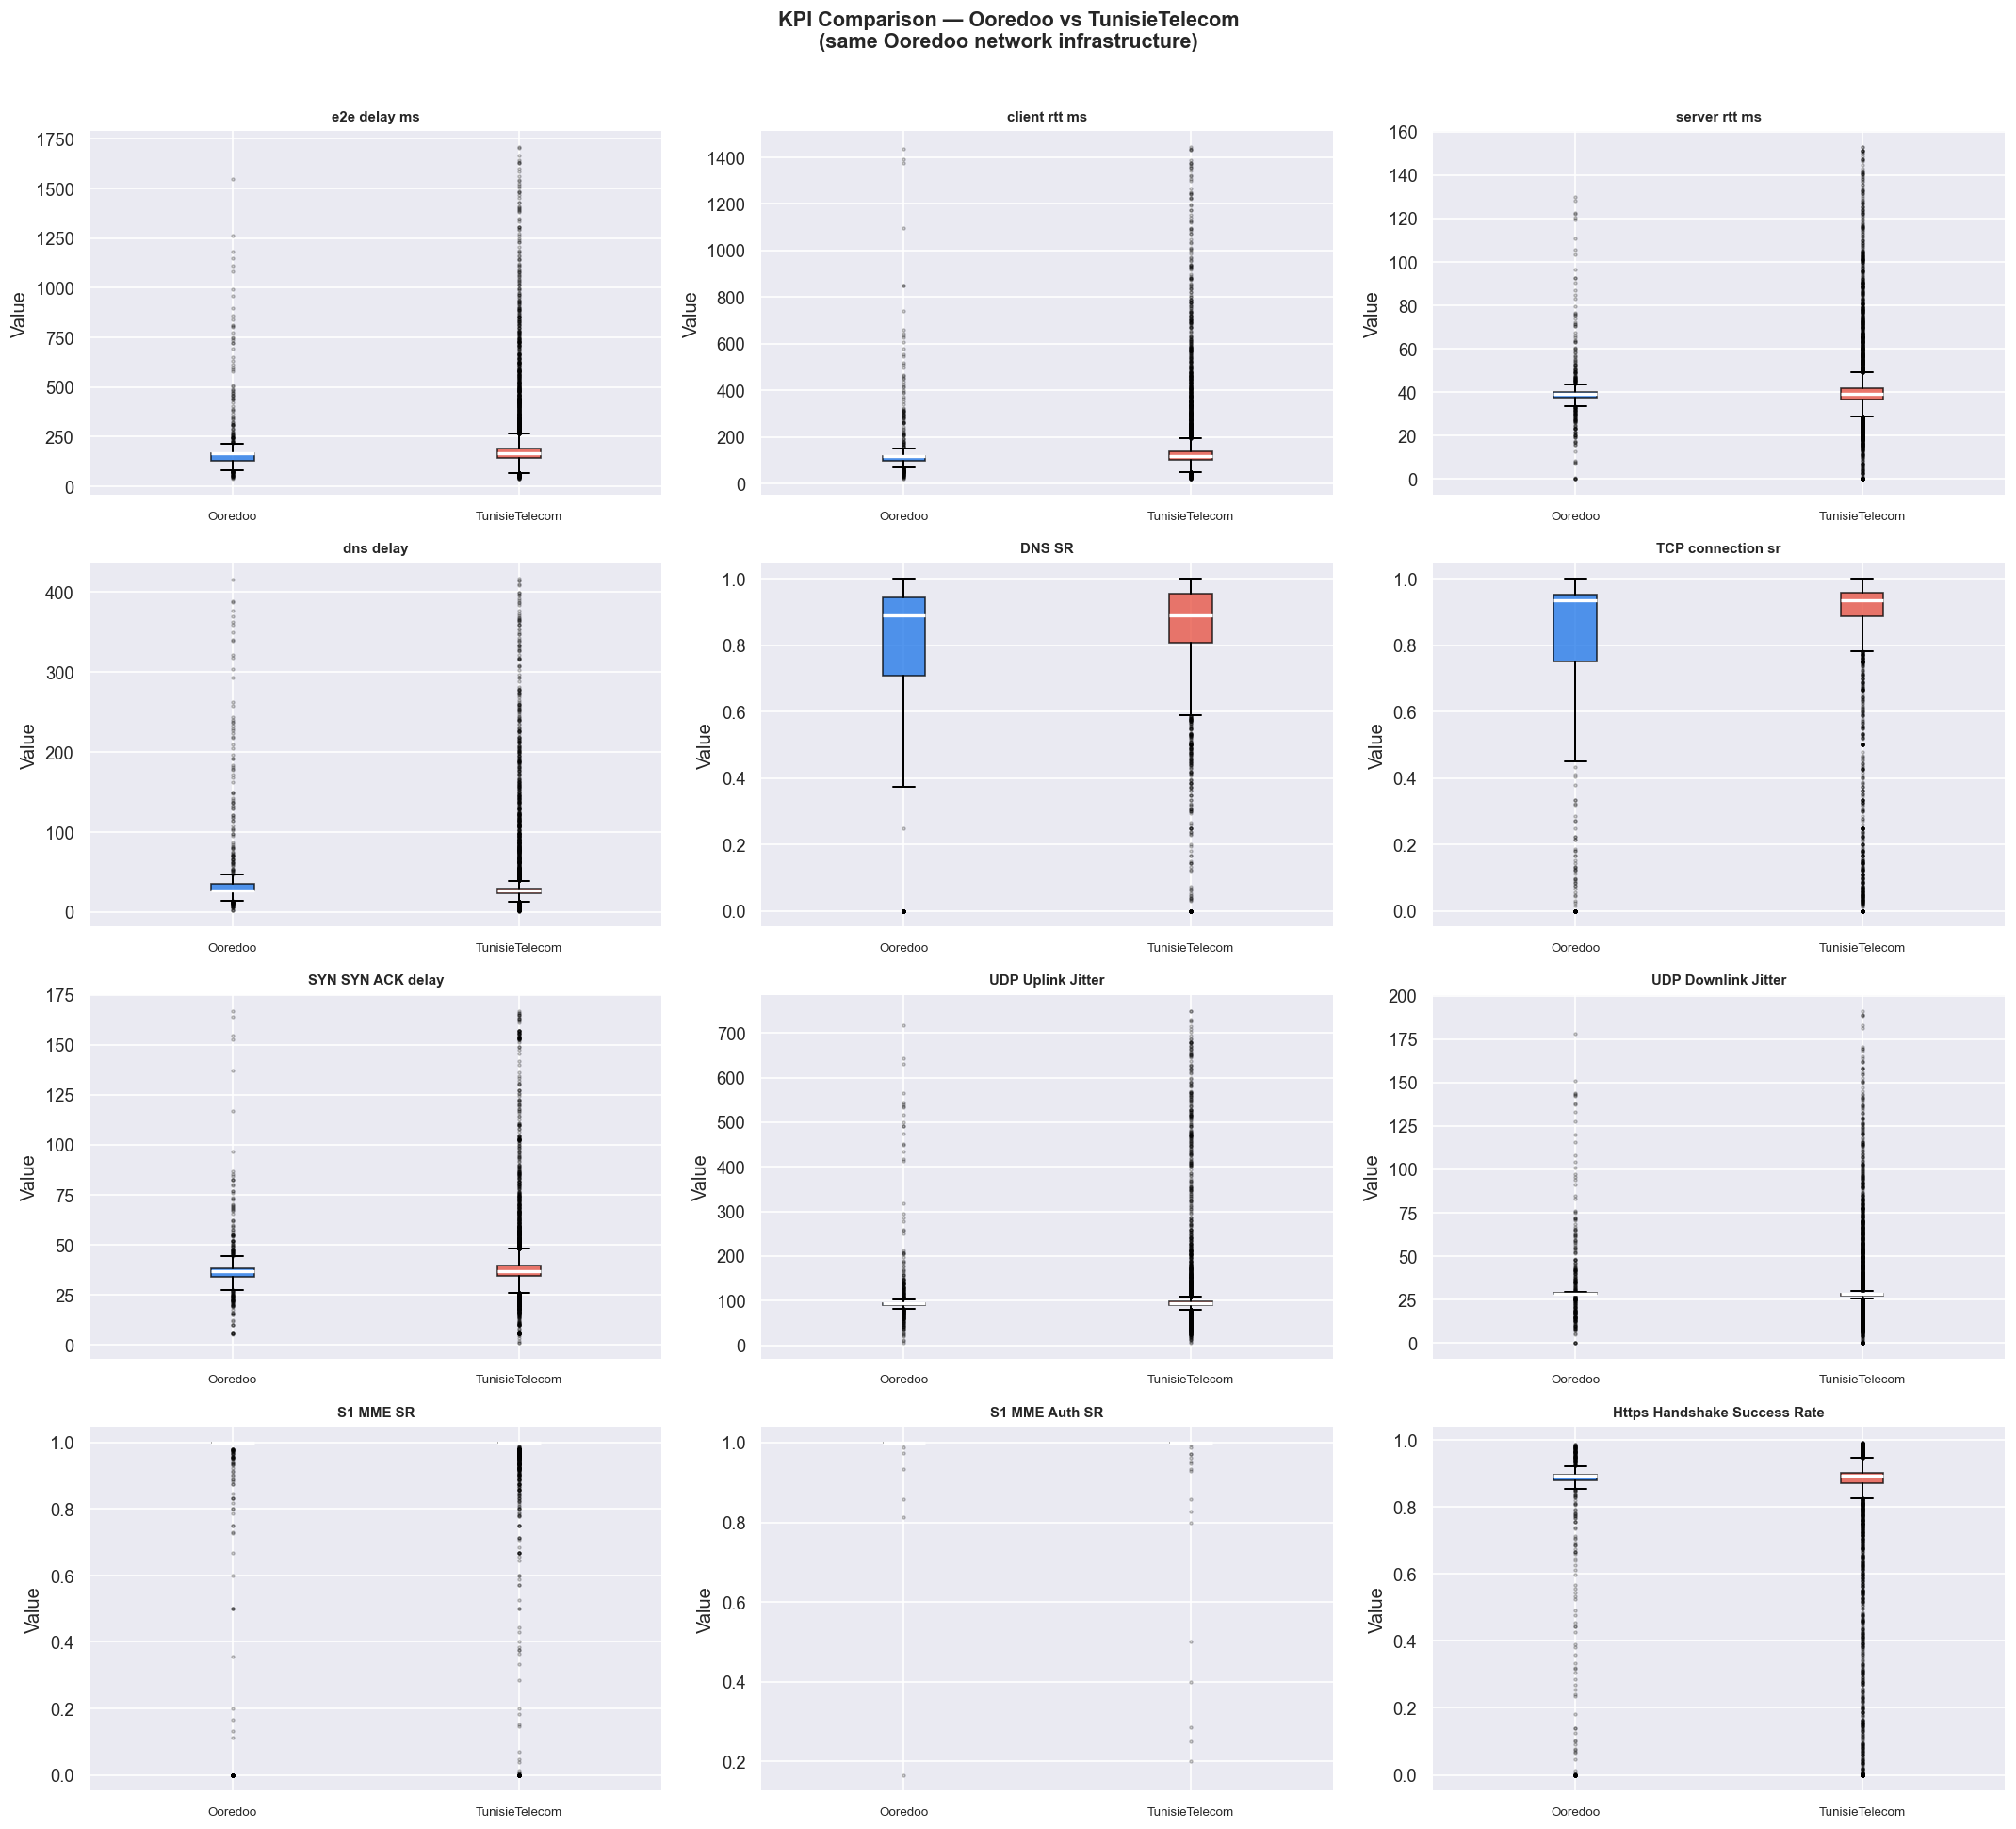

KPI Comparison — Ooredoo vs TunisieTelecom
  KPI                                              Ooredoo TunisieTel    Diff%    p-value Sig
  --------------------------------------------- ---------- ---------- -------- ---------- ----
  e2e_delay_ms                                     164.333    164.333    +0.0%     0.0437 *   ≈
  client_rtt_ms                                    118.405    118.405    +0.0%     0.0505     ≈
  server_rtt_ms                                     39.353     39.353    +0.0%     0.4955     ≈
  dns_delay                                         26.378     26.378    +0.0%     0.0008 *** ≈
  DNS_SR                                             0.889      0.889    +0.0%     0.0031 **  ≈
  TCP_connection_sr                                  0.935      0.935    +0.0%     0.0002 *** ≈
  SYN_SYN_ACK_delay                                 37.029     37.029    +0.0%     0.1771     ≈
  UDP_Uplink_Jitter                                 94.648     94.648    +0.0%     0.5977     ≈


In [15]:
# ── Cellule 15 — KPI par Opérateur : Ooredoo vs TunisieTelecom ────────────
# Objectif : comparer l'expérience réseau entre opérateurs sur le même réseau
# Ooredoo (529) = abonnés natifs  |  TunisieTelecom (4,365) = roaming IN
# Si KPI identiques → problème radio (infrastructure commune)
# Si KPI différents → problème core/config spécifique à un opérateur

# ── KPIs fiables (0% nulls, valeurs non constantes) ──────────────────────
KPI_COMPARE = [
    'e2e_delay_ms',
    'client_rtt_ms',
    'server_rtt_ms',
    'dns_delay',
    'DNS_SR',
    'TCP_connection_sr',
    'SYN_SYN_ACK_delay',
    'UDP_Uplink_Jitter',
    'UDP_Downlink_Jitter',
    'S1_MME_SR',
    'S1_MME_Auth_SR',
    'Https_Handshake_Success_Rate',
]
KPI_COMPARE = [c for c in KPI_COMPARE if c in dc.columns]

ops = ['Ooredoo', 'TunisieTelecom']
dc_ops = dc[dc['operator'].isin(ops)].copy()

# ── 1. Boxplots KPI par opérateur ─────────────────────────────────────────
n_cols = 3
n_rows = (len(KPI_COMPARE) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

op_palette = {'Ooredoo': C_DATA, 'TunisieTelecom': C_VOICE}

for i, col in enumerate(KPI_COMPARE):
    data_plot = dc_ops[[col, 'operator']].dropna()
    q99 = data_plot[col].quantile(0.99)
    data_plot = data_plot[data_plot[col] <= q99]

    groups = [data_plot[data_plot['operator'] == op][col].values
              for op in ops if op in data_plot['operator'].unique()]
    labels  = [op for op in ops
               if op in data_plot['operator'].unique()]
    colors  = [op_palette[op] for op in labels]

    bp = axes[i].boxplot(groups, labels=labels, patch_artist=True,
                          medianprops=dict(color='white', linewidth=2),
                          whiskerprops=dict(linewidth=1.2),
                          capprops=dict(linewidth=1.2),
                          flierprops=dict(marker='.', markersize=3,
                                          alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    axes[i].set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', labelsize=8)

for j in range(len(KPI_COMPARE), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('KPI Comparison — Ooredoo vs TunisieTelecom\n'
             '(same Ooredoo network infrastructure)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'eda_dc_kpi_by_operator.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Statistical comparison table ───────────────────────────────────────
from scipy import stats

print('KPI Comparison — Ooredoo vs TunisieTelecom')
print(f'  {"KPI":<45} {"Ooredoo":>10} {"TunisieTel":>10} '
      f'{"Diff%":>8} {"p-value":>10} {"Sig"}')
print(f'  {"-"*45} {"-"*10} {"-"*10} {"-"*8} {"-"*10} {"-"*4}')

for col in KPI_COMPARE:
    oo  = dc[dc['operator'] == 'Ooredoo'][col].dropna()
    tt  = dc[dc['operator'] == 'TunisieTelecom'][col].dropna()
    if len(oo) < 5 or len(tt) < 5:
        continue

    med_oo = oo.median()
    med_tt = tt.median()
    diff_pct = (med_oo - med_tt) / (med_tt + 1e-9) * 100

    # Mann-Whitney U test (non-parametric — distributions not normal)
    _, p_val = stats.mannwhitneyu(oo, tt, alternative='two-sided')
    sig = '***' if p_val < 0.001 else '** ' if p_val < 0.01 \
          else '*  ' if p_val < 0.05 else '   '

    # Flag direction
    arrow = '↑' if diff_pct > 5 else '↓' if diff_pct < -5 else '≈'
    print(f'  {col:<45} {med_oo:>10.3f} {med_tt:>10.3f} '
          f'{diff_pct:>+7.1f}% {p_val:>10.4f} {sig} {arrow}')

print()
print('Significance: *** p<0.001  ** p<0.01  * p<0.05')
print('Diff% = (Ooredoo - TunisieTelecom) / TunisieTelecom')
print('↑ = Ooredoo higher  ↓ = Ooredoo lower  ≈ = similar')

In [16]:
# ── Cellule 15b — Diagnostic : distribution complète Ooredoo vs TT ────────

print('Percentile comparison — Ooredoo vs TunisieTelecom:')
print(f'  {"KPI":<35} {"P10_OO":>8} {"P10_TT":>8} '
      f'{"P90_OO":>8} {"P90_TT":>8} {"P99_OO":>8} {"P99_TT":>8}')
print(f'  {"-"*35} {"-"*8} {"-"*8} {"-"*8} {"-"*8} {"-"*8} {"-"*8}')

for col in KPI_COMPARE:
    oo = dc[dc['operator'] == 'Ooredoo'][col].dropna()
    tt = dc[dc['operator'] == 'TunisieTelecom'][col].dropna()
    if len(oo) < 5 or len(tt) < 5:
        continue
    print(f'  {col:<35} '
          f'{oo.quantile(0.10):>8.2f} {tt.quantile(0.10):>8.2f} '
          f'{oo.quantile(0.90):>8.2f} {tt.quantile(0.90):>8.2f} '
          f'{oo.quantile(0.99):>8.2f} {tt.quantile(0.99):>8.2f}')

Percentile comparison — Ooredoo vs TunisieTelecom:
  KPI                                   P10_OO   P10_TT   P90_OO   P90_TT   P99_OO   P99_TT
  ----------------------------------- -------- -------- -------- -------- -------- --------
  e2e_delay_ms                           86.55    86.35   368.90   442.04  1942.06  1678.70
  client_rtt_ms                          53.75    58.02   288.21   348.98  1424.47  1446.14
  server_rtt_ms                          28.14    26.43    52.52    67.10   121.61   160.15
  dns_delay                              15.60    11.95   128.92    93.80   387.79   418.06
  DNS_SR                                  0.00     0.00     0.99     0.99     1.00     1.00
  TCP_connection_sr                       0.00     0.08     0.98     0.98     1.00     1.00
  SYN_SYN_ACK_delay                      24.47    25.68    51.79    56.95   161.29   168.11
  UDP_Uplink_Jitter                      66.79    64.76   146.28   155.25   697.05   750.16
  UDP_Downlink_Jitter        

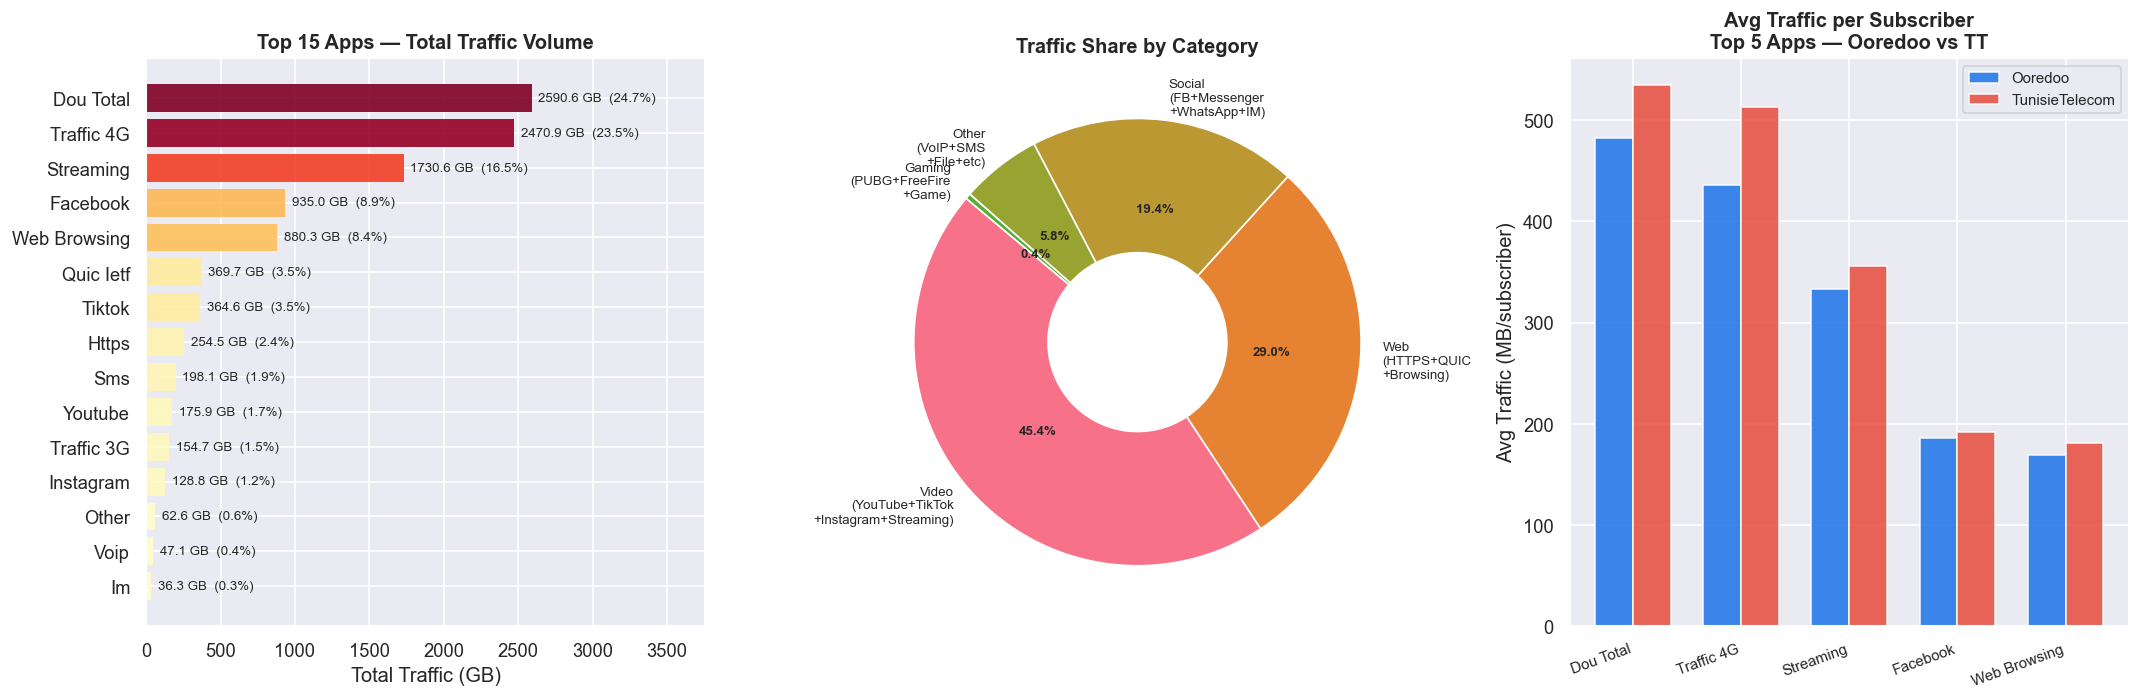

Top 10 apps by total traffic:
  App                                   Total GB  % Share
  ----------------------------------- ---------- --------
  Dou Total                              2590.59    24.7%
  Traffic 4G                             2470.87    23.5%
  Streaming                              1730.56    16.5%
  Facebook                                934.96     8.9%
  Web Browsing                            880.26     8.4%
  Quic Ietf                               369.74     3.5%
  Tiktok                                  364.64     3.5%
  Https                                   254.53     2.4%
  Sms                                     198.12     1.9%
  Youtube                                 175.91     1.7%

  Total measured traffic : 10503.2 GB
  Avg per subscriber     : 2144.4 MB


In [17]:
# ── Cellule 16 — App Traffic Ranking ──────────────────────────────────────
# Objectif : identifier les applications dominantes en volume de trafic
# Utile pour : dimensionnement réseau, priorisation QoS, analyse des plaintes

# ── Traffic columns présentes ──────────────────────────────────────────────
traffic_cols = [c for c in COLS_TRAFFIC if c in dc.columns
                and c not in ('duration', 'voice_onlinetime_2g',
                               'voice_onlinetime_3g', 'night_traffic',
                               'day_traffic', 'late_night_traffic')]

# Total traffic per app (sum across all subscribers)
app_totals = (dc[traffic_cols].sum()
                .sort_values(ascending=False)
                .reset_index())
app_totals.columns = ['app', 'total_bytes']
app_totals['total_gb']  = app_totals['total_bytes'] / 1e9
app_totals['pct']       = app_totals['total_bytes'] / app_totals['total_bytes'].sum() * 100
app_totals['app_clean'] = (app_totals['app']
                            .str.replace('_traffic', '')
                            .str.replace('_', ' ')
                            .str.title())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Top 15 apps by total volume ────────────────────────────────────────
top15 = app_totals.head(15).sort_values('total_gb')
norm  = plt.Normalize(top15['total_gb'].min(), top15['total_gb'].max())
colors = plt.cm.YlOrRd(norm(top15['total_gb'].values))

bars = axes[0].barh(top15['app_clean'], top15['total_gb'],
                     color=colors, edgecolor='none', alpha=0.9)
axes[0].bar_label(bars,
                  labels=[f'{v:.1f} GB  ({p:.1f}%)'
                           for v, p in zip(top15['total_gb'],
                                           top15['pct'])],
                  padding=4, fontsize=8)
axes[0].set_xlim(0, top15['total_gb'].max() * 1.45)
axes[0].set_title('Top 15 Apps — Total Traffic Volume',
                   fontweight='bold')
axes[0].set_xlabel('Total Traffic (GB)')

# ── 2. Donut — traffic category share ─────────────────────────────────────
# Group apps into categories
categories = {
    'Video\n(YouTube+TikTok\n+Instagram+Streaming)': [
        'YouTube_traffic', 'TikTok_traffic',
        'Instagram_traffic', 'Streaming_traffic',
    ],
    'Social\n(FB+Messenger\n+WhatsApp+IM)': [
        'Facebook_traffic', 'Facebook_Messenger_traffic',
        'WhatsApp_traffic', 'IM_traffic',
    ],
    'Web\n(HTTPS+QUIC\n+Browsing)': [
        'HTTPS_traffic', 'QUIC_IETF_traffic',
        'Web_Browsing_traffic', 'Google_Common_traffic',
        'GoogleSearch_traffic',
    ],
    'Gaming\n(PUBG+FreeFire\n+Game)': [
        'PUBG_traffic', 'FreeFire_traffic', 'game_traffic',
    ],
    'Other\n(VoIP+SMS\n+File+etc)': [
        'VoIP_traffic', 'SMS_traffic', 'Other_traffic',
        'Speedtest_traffic', 'nPerf_traffic',
    ],
}
cat_totals = {}
for cat, cols in categories.items():
    present = [c for c in cols if c in dc.columns]
    cat_totals[cat] = dc[present].sum().sum() if present else 0

cat_series = pd.Series(cat_totals).sort_values(ascending=False)
cat_colors = [COLORS[i] for i in range(len(cat_series))]

wedges, texts, autotexts = axes[1].pie(
    cat_series.values,
    labels=cat_series.index,
    autopct='%1.1f%%',
    colors=cat_colors,
    startangle=140,
    wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=8),
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(8)
axes[1].set_title('Traffic Share by Category', fontweight='bold')

# ── 3. Traffic per subscriber by operator ─────────────────────────────────
top5_apps = app_totals.head(5)['app'].tolist()

op_app = (dc[dc['operator'].isin(['Ooredoo', 'TunisieTelecom'])]
           .groupby('operator')[top5_apps]
           .mean()
           .T
           .reset_index())
op_app.columns = ['app', 'Ooredoo', 'TunisieTelecom']
op_app['app'] = (op_app['app'].str.replace('_traffic', '')
                               .str.replace('_', ' ').str.title())
op_app['Ooredoo']        /= 1e6   # convert to MB
op_app['TunisieTelecom'] /= 1e6

x = np.arange(len(op_app))
w = 0.35
axes[2].bar(x - w/2, op_app['Ooredoo'],        w,
            color=C_DATA,  alpha=0.85, label='Ooredoo')
axes[2].bar(x + w/2, op_app['TunisieTelecom'], w,
            color=C_VOICE, alpha=0.85, label='TunisieTelecom')
axes[2].set_xticks(x)
axes[2].set_xticklabels(op_app['app'], rotation=20,
                         ha='right', fontsize=9)
axes[2].set_title('Avg Traffic per Subscriber\nTop 5 Apps — Ooredoo vs TT',
                   fontweight='bold')
axes[2].set_ylabel('Avg Traffic (MB/subscriber)')
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_dc_app_traffic.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────
print('Top 10 apps by total traffic:')
print(f'  {"App":<35} {"Total GB":>10} {"% Share":>8}')
print(f'  {"-"*35} {"-"*10} {"-"*8}')
for _, row in app_totals.head(10).iterrows():
    print(f'  {row["app_clean"]:<35} {row["total_gb"]:>10.2f} '
          f'{row["pct"]:>7.1f}%')

total_gb = app_totals['total_gb'].sum()
print(f'\n  Total measured traffic : {total_gb:.1f} GB')
print(f'  Avg per subscriber     : '
      f'{total_gb*1e9/len(dc)/1e6:.1f} MB')

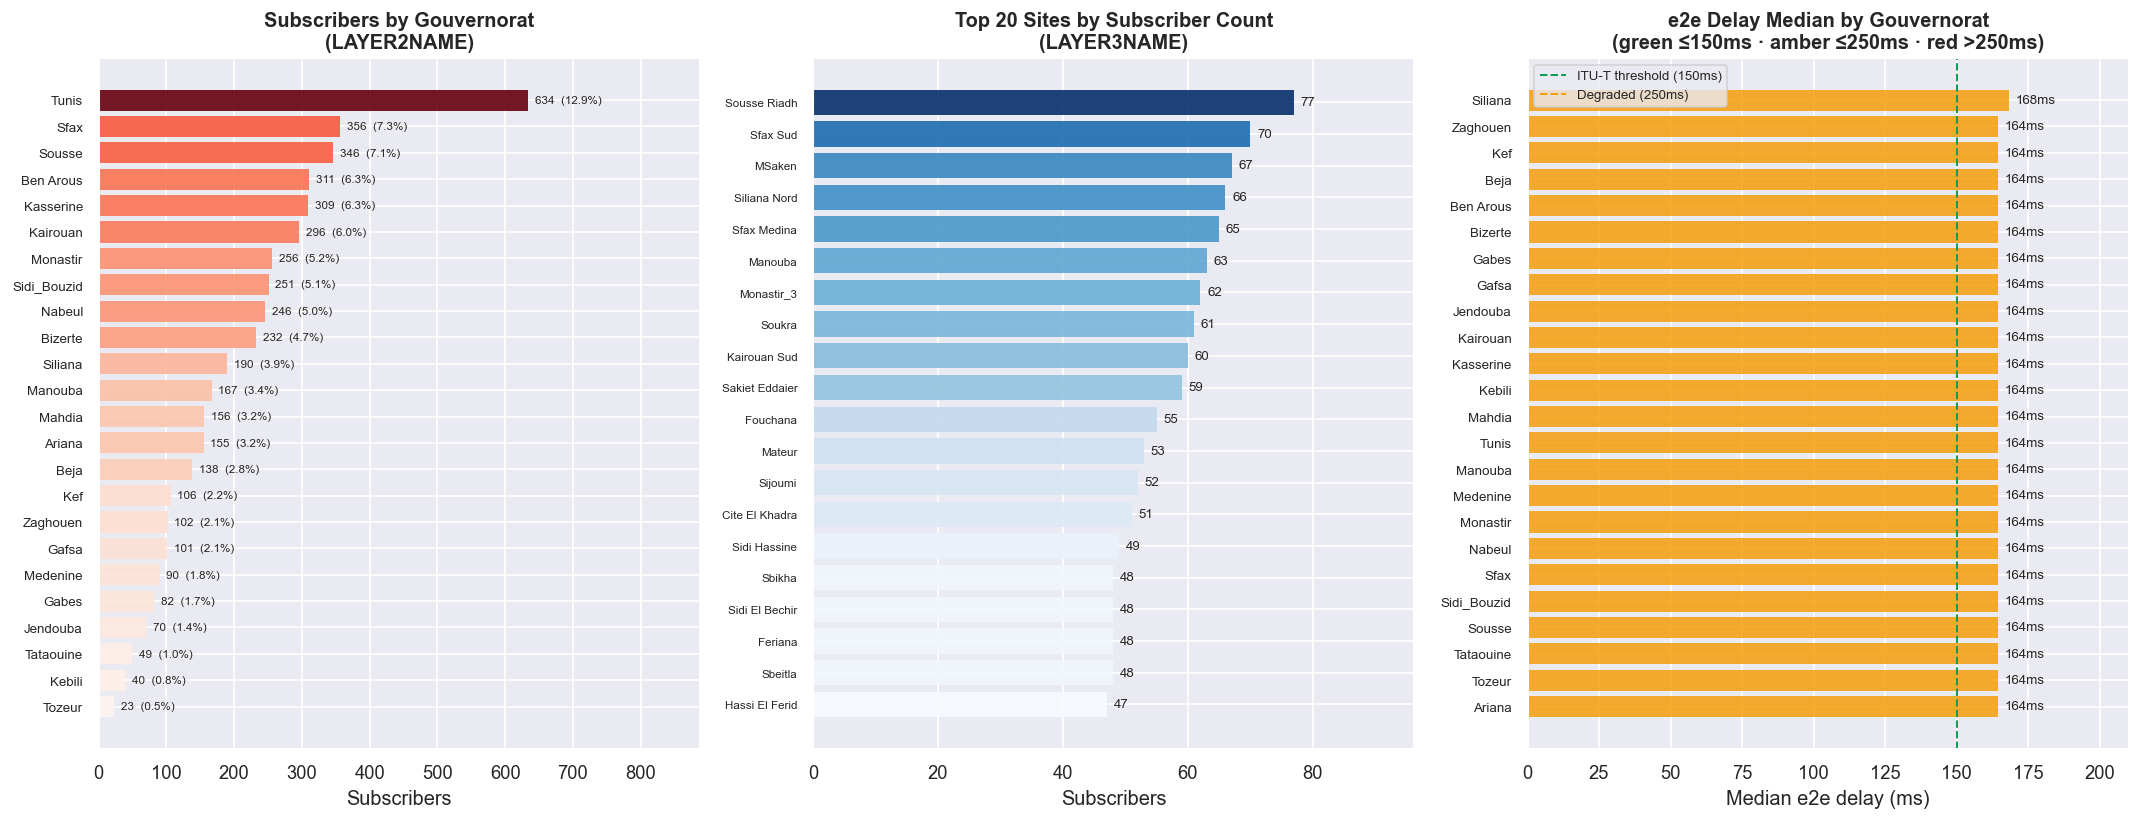

Subscribers by Gouvernorat × Operator:
  Gouvernorat                     Ooredoo       TT    Other    Total    OO%
  ------------------------------ -------- -------- -------- -------- ------
  Ben Arous                            40      271        0      311  12.9%
  Sidi_Bouzid                           4      247        0      251   1.6%
  Sousse                               60      286        0      346  17.3%
  Bizerte                              37      195        0      232  15.9%
  Monastir                             31      225        0      256  12.1%
  Kef                                   6      100        0      106   5.7%
  Tunis                               104      530        0      634  16.4%
  Kasserine                             4      305        0      309   1.3%
  Zaghouen                              6       96        0      102   5.9%
  Sfax                                 42      314        0      356  11.8%
  Mahdia                               12      14

In [18]:
# ── Cellule 17 — Geographic Distribution (LAYER2 + LAYER3) ────────────────
# LAYER2NAME = gouvernorat (24) — niveau analyse principale
# LAYER3NAME = cellule/secteur (255) — niveau site granulaire
# longitude/latitude disponibles → carte possible

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ── 1. Subscribers by gouvernorat (LAYER2) ────────────────────────────────
reg_counts = (dc['region'].value_counts()
                           .dropna()
                           .sort_values(ascending=True))

norm   = plt.Normalize(reg_counts.min(), reg_counts.max())
colors = plt.cm.Reds(norm(reg_counts.values))

bars = axes[0].barh(reg_counts.index, reg_counts.values,
                     color=colors, edgecolor='none', alpha=0.9)
axes[0].bar_label(bars,
                  labels=[f'{v:,}  ({v/len(dc)*100:.1f}%)'
                           for v in reg_counts.values],
                  padding=4, fontsize=7)
axes[0].set_xlim(0, reg_counts.max() * 1.40)
axes[0].set_title('Subscribers by Gouvernorat\n(LAYER2NAME)',
                   fontweight='bold')
axes[0].set_xlabel('Subscribers')
axes[0].tick_params(axis='y', labelsize=8)

# ── 2. Top 20 sites by subscriber count (LAYER3) ──────────────────────────
if 'LAYER3NAME' in dc.columns:
    site_counts = (dc['LAYER3NAME'].value_counts()
                                    .head(20)
                                    .sort_values(ascending=True))
    norm_s  = plt.Normalize(site_counts.min(), site_counts.max())
    colors_s = plt.cm.Blues(norm_s(site_counts.values))

    bars2 = axes[1].barh(site_counts.index, site_counts.values,
                          color=colors_s, edgecolor='none', alpha=0.9)
    axes[1].bar_label(bars2,
                      labels=[f'{v:,}' for v in site_counts.values],
                      padding=4, fontsize=8)
    axes[1].set_xlim(0, site_counts.max() * 1.25)
    axes[1].set_title('Top 20 Sites by Subscriber Count\n(LAYER3NAME)',
                       fontweight='bold')
    axes[1].set_xlabel('Subscribers')
    axes[1].tick_params(axis='y', labelsize=7)
else:
    axes[1].text(0.5, 0.5, 'LAYER3NAME not found',
                 ha='center', va='center',
                 transform=axes[1].transAxes)

# ── 3. KPI quality by gouvernorat (e2e_delay median) ─────────────────────
if 'e2e_delay_ms' in dc.columns:
    kpi_by_reg = (dc.groupby('region')['e2e_delay_ms']
                    .agg(['median', 'mean', 'count'])
                    .reset_index()
                    .sort_values('median', ascending=True))

    # Color by quality: green=good, red=bad (threshold 150ms ITU-T)
    bar_colors = ['#0F9D58' if v <= 150 else
                  '#F59E0B' if v <= 250 else
                  '#CF0A2C'
                  for v in kpi_by_reg['median']]

    bars3 = axes[2].barh(kpi_by_reg['region'],
                          kpi_by_reg['median'],
                          color=bar_colors, edgecolor='none', alpha=0.85)
    axes[2].bar_label(bars3,
                      labels=[f'{v:.0f}ms'
                               for v in kpi_by_reg['median']],
                      padding=4, fontsize=8)
    axes[2].axvline(150, color='#0F9D58', linestyle='--',
                    linewidth=1.2, label='ITU-T threshold (150ms)')
    axes[2].axvline(250, color='#F59E0B', linestyle='--',
                    linewidth=1.2, label='Degraded (250ms)')
    axes[2].set_xlim(0, kpi_by_reg['median'].max() * 1.25)
    axes[2].set_title('e2e Delay Median by Gouvernorat\n'
                       '(green ≤150ms · amber ≤250ms · red >250ms)',
                       fontweight='bold')
    axes[2].set_xlabel('Median e2e delay (ms)')
    axes[2].tick_params(axis='y', labelsize=8)
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'e2e_delay_ms not found',
                 ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_dc_geographic.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Cross-table : gouvernorat × operator ────────────────────────────────
ct = pd.crosstab(dc['region'], dc['operator'],
                  margins=True, margins_name='Total')
ct_pct = (pd.crosstab(dc['region'], dc['operator'], normalize='index')
            .mul(100).round(1))

print('Subscribers by Gouvernorat × Operator:')
print(f'  {"Gouvernorat":<30} {"Ooredoo":>8} {"TT":>8} '
      f'{"Other":>8} {"Total":>8} {"OO%":>6}')
print(f'  {"-"*30} {"-"*8} {"-"*8} {"-"*8} {"-"*8} {"-"*6}')

for reg in dc['region'].dropna().unique():
    row   = ct.loc[reg] if reg in ct.index else {}
    oo    = int(row.get('Ooredoo', 0))
    tt    = int(row.get('TunisieTelecom', 0))
    other = int(row.get('Unknown', 0))
    total = oo + tt + other
    oo_pct = oo / total * 100 if total > 0 else 0
    print(f'  {reg:<30} {oo:>8,} {tt:>8,} '
          f'{other:>8,} {total:>8,} {oo_pct:>5.1f}%')

# ── 5. KPI summary by gouvernorat ─────────────────────────────────────────
if 'e2e_delay_ms' in dc.columns:
    print('\ne2e delay by gouvernorat:')
    print(f'  {"Gouvernorat":<30} {"Median":>8} {"Mean":>8} '
          f'{"P90":>8} {"n":>6} {"Quality"}')
    print(f'  {"-"*30} {"-"*8} {"-"*8} {"-"*8} {"-"*6} {"-"*8}')
    for _, row in kpi_by_reg.sort_values('median',
                                          ascending=False).iterrows():
        quality = ('✓ Good'   if row['median'] <= 150 else
                   '~ Fair'   if row['median'] <= 250 else
                   '✗ Poor')
        p90 = dc[dc['region'] == row['region']]['e2e_delay_ms'].quantile(0.9)
        print(f'  {row["region"]:<30} {row["median"]:>8.1f} '
              f'{row["mean"]:>8.1f} {p90:>8.1f} '
              f'{int(row["count"]):>6,} {quality}')

In [19]:
# ── Fix join keys ──────────────────────────────────────────────────────────

# 1. MSISDN : supprimer le .0 dans complaints
complaints['msisdn'] = (complaints['msisdn'].astype(str)
                        .str.replace(r'\.0$', '', regex=True)
                        .str.strip())

# 2. Region : aligner les noms
#    dc  → "Ariana"             (LAYER2NAME sans suffixe)
#    cc  → "Ariana Gouvernorat" (province avec suffixe)
# Solution : ajouter " Gouvernorat" aux régions dc pour matcher cc
dc['region_join'] = dc['region'].str.strip() + ' Gouvernorat'

# Vérification
print("MSISDN fix:")
print(f"  cc sample : {complaints['msisdn'].head(3).tolist()}")
print(f"  dc sample : {dc['msisdn'].head(3).tolist()}")

print("\nRegion fix:")
dc_regs = sorted(dc['region_join'].dropna().unique().tolist())
cc_regs = sorted(complaints[C_REGION].dropna().unique().tolist())
matched = set(dc_regs) & set(cc_regs)
print(f"  dc regions (with suffix) : {dc_regs[:4]}")
print(f"  cc regions               : {cc_regs[:4]}")
print(f"  Matched regions          : {len(matched)} / {len(dc_regs)}")
# ── Debug les 5 régions non matchées ──────────────────────────────────────
dc_regs_set = set(dc['region_join'].dropna().unique())
cc_regs_set = set(complaints[C_REGION].dropna().unique())

print("Régions dans dc NON trouvées dans cc:")
for r in sorted(dc_regs_set - cc_regs_set):
    print(f"  dc  → '{r}'")

print("\nRégions dans cc NON trouvées dans dc:")
for r in sorted(cc_regs_set - dc_regs_set):
    print(f"  cc  → '{r}'")

MSISDN fix:
  cc sample : ['21100376', '26136691', '24475205']
  dc sample : ['92411456', '94333771', '97860919']

Region fix:
  dc regions (with suffix) : ['Ariana Gouvernorat', 'Beja Gouvernorat', 'Ben Arous Gouvernorat', 'Bizerte Gouvernorat']
  cc regions               : ['Ariana Gouvernorat', 'Ben Arous Gouvernorat', 'Bizerte Gouvernorat', 'Béja Gouvernorat']
  Matched regions          : 19 / 24
Régions dans dc NON trouvées dans cc:
  dc  → 'Beja Gouvernorat'
  dc  → 'Gabes Gouvernorat'
  dc  → 'Medenine Gouvernorat'
  dc  → 'Sidi_Bouzid Gouvernorat'
  dc  → 'Zaghouen Gouvernorat'

Régions dans cc NON trouvées dans dc:
  cc  → 'Béja Gouvernorat'
  cc  → 'Gabès Gouvernorat'
  cc  → 'Mednine Gouvernorat'
  cc  → 'Sidi Bouzid Gouvernorat'
  cc  → 'Zaghouan Gouvernorat'


In [20]:
# ── Cellule 18 — Validation croisée régionale : KPI vs Plaintes ───────────
# Pas un join — une comparaison spatiale entre deux sources indépendantes
# Question : les régions avec beaucoup de plaintes ont-elles aussi
#            de mauvais KPI réseau ?

# KPI médian par gouvernorat (dc)
dc_reg = (dc.groupby('region_join')[KPI_JOIN]
            .median()
            .reset_index()
            .rename(columns={'region_join': 'region'}))

# Plaintes par gouvernorat (Sheet1)
comp_reg = (complaints.groupby(C_REGION)
                       .size()
                       .reset_index(name='n_complaints'))

# Merge
joined_reg = dc_reg.merge(comp_reg, on='region', how='inner')
print(f'Gouvernorats matchés : {len(joined_reg)} / 24')

# Corrélation spatiale
from scipy import stats
print(f'\nCorrélation spatiale KPI vs plaintes ({len(joined_reg)} gouvernorats):')
print(f'  {"KPI":<45} {"r":>8} {"p-value":>10} {"Sig"}')
print(f'  {"-"*45} {"-"*8} {"-"*10} {"-"*4}')

for col in KPI_JOIN:
    if col not in joined_reg.columns:
        continue
    data = joined_reg[[col, 'n_complaints']].dropna()
    if len(data) < 4:
        continue
    r, p = stats.pearsonr(data[col], data['n_complaints'])
    sig  = '***' if p < 0.001 else '**' if p < 0.01 \
           else '*' if p < 0.05 else ''
    print(f'  {col:<45} {r:>+8.3f} {p:>10.4f} {sig}')

# Scatter e2e vs plaintes par région
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(joined_reg['e2e_delay_ms'],
           joined_reg['n_complaints'],
           s=80, alpha=0.8, color=COLORS[3])
for _, row in joined_reg.iterrows():
    ax.annotate(
        row['region'].replace(' Gouvernorat', ''),
        xy=(row['e2e_delay_ms'], row['n_complaints']),
        xytext=(4, 4), textcoords='offset points',
        fontsize=8, alpha=0.85
    )
r_val, p_val = stats.pearsonr(
    joined_reg['e2e_delay_ms'].dropna(),
    joined_reg.loc[joined_reg['e2e_delay_ms'].notna(), 'n_complaints']
)
z = np.polyfit(joined_reg['e2e_delay_ms'].dropna(),
               joined_reg.loc[joined_reg['e2e_delay_ms'].notna(),
                               'n_complaints'], 1)
xs = np.linspace(joined_reg['e2e_delay_ms'].min(),
                 joined_reg['e2e_delay_ms'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), color=HUAWEI_RED, linewidth=2)
ax.set_title(f'Validation croisée régionale\n'
             f'e2e Delay (dc) vs Nombre de plaintes (Sheet1)\n'
             f'r={r_val:+.3f}  p={p_val:.4f}',
             fontweight='bold')
ax.set_xlabel('Median e2e_delay_ms par gouvernorat (dataCollectionist)')
ax.set_ylabel('Total plaintes par gouvernorat (Sheet1)')
plt.tight_layout()
plt.savefig(FIGURES / 'eda_regional_kpi_vs_complaints.png',
            dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'KPI_JOIN' is not defined

In [ ]:
# ── Debug NaN correlations ─────────────────────────────────────────────────
print("KPI variance par gouvernorat (std de la médiane):")
for col in KPI_JOIN:
    if col in joined_reg.columns:
        std = joined_reg[col].std()
        n_null = joined_reg[col].isna().sum()
        print(f"  {col:<45} std={std:.4f}  nulls={n_null}")

In [ ]:
# ── Cellule 19 — Synthèse EDA ─────────────────────────────────────────────
# Résumé complet des findings D1 pour la thèse

import os
from scipy import stats

print('=' * 65)
print('  D1 — EDA REPORT — RÉSULTATS CLÉS')
print('=' * 65)

# ── Section 1 : Sheet1 — Complaints ───────────────────────────────────────
print('\n  ── SHEET1 — COMPLAINTS ──────────────────────────────────')
print(f'  Total plaintes       : {len(complaints):,}')
print(f'  Période              : {complaints[C_TIMESTAMP].min().date()} → '
      f'{complaints[C_TIMESTAMP].max().date()}')
print(f'  MSISDNs uniques      : {complaints[C_MSISDN].nunique():,}  '
      f'({complaints[C_MSISDN].nunique()/len(complaints)*100:.1f}%)')
print(f'  Régions              : {complaints[C_REGION].nunique()}  '
      f'(tous gouvernorats tunisiens)')
print(f'  Villes               : {complaints[C_CITY].nunique()}')

# Operator split
oo_n = (complaints['operator'] == 'Ooredoo').sum()
tt_n = (complaints['operator'] == 'TunisieTelecom').sum()
unk_n = (complaints['operator'] == 'Unknown').sum()
print(f'\n  Operator split:')
print(f'    Ooredoo            : {oo_n:>7,}  ({oo_n/len(complaints)*100:.1f}%)')
print(f'    TunisieTelecom     : {tt_n:>7,}  ({tt_n/len(complaints)*100:.1f}%)')
print(f'    Unknown            : {unk_n:>7,}  ({unk_n/len(complaints)*100:.1f}%)')

# Service type
print(f'\n  Service type split:')
if C_TYPE in complaints.columns:
    for svc, cnt in complaints[C_TYPE].value_counts().items():
        print(f'    {svc:<18} : {cnt:>7,}  ({cnt/len(complaints)*100:.1f}%)')

# Temporal peaks
top_reg  = complaints[C_REGION].value_counts().index[0]
top_cat  = complaints[C_CATEGORY].value_counts().index[0]
peak_hr  = int(complaints['hour'].value_counts().idxmax())
peak_day = complaints['day_of_week'].value_counts().index[0]
print(f'\n  Top région           : {top_reg}')
print(f'  Top catégorie        : {top_cat}')
print(f'  Heure de pointe      : {peak_hr:02d}h00')
print(f'  Jour de pointe       : {peak_day}')

# ── Section 2 : dataCollectionist ─────────────────────────────────────────
print('\n  ── dataCollectionist — NETWORK KPI SNAPSHOT ────────────')
print(f'  Abonnés mesurés      : {len(dc):,}')
print(f'  Date snapshot        : 2026-03-13')
n_gov = dc['region_join'].nunique() if 'region_join' in dc.columns \
        else dc['region'].nunique()
print(f'  Gouvernorats couverts: {n_gov}')

print(f'  Sites mesurés        : {dc["LAYER3NAME"].nunique()
      if "LAYER3NAME" in dc.columns else "N/A"}')
print(f'  Colonnes KPI réelles : {len(COLS_KPI_ALL)}')
print(f'  Colonnes trafic apps : {len(COLS_TRAFFIC)}')

print(f'\n  Operator split:')
for op, cnt in dc['operator'].value_counts().items():
    print(f'    {op:<22} : {cnt:>6,}  ({cnt/len(dc)*100:.1f}%)')

# Key KPI findings
print(f'\n  KPI findings:')
if 'e2e_delay_ms' in dc.columns:
    e2e_med = dc['e2e_delay_ms'].median()
    e2e_p90 = dc['e2e_delay_ms'].quantile(0.90)
    status  = '✗ Above ITU-T 150ms' if e2e_med > 150 else '✓ OK'
    print(f'  e2e_delay median     : {e2e_med:.1f}ms  '
          f'P90={e2e_p90:.1f}ms  [{status}]')
if 'UDP_Uplink_Jitter' in dc.columns:
    jitter = dc['UDP_Uplink_Jitter'].median()
    print(f'  UDP Uplink Jitter    : {jitter:.1f}ms  '
          f'[{"✗ High (>30ms)" if jitter > 30 else "✓ OK"}]')
if 'dns_delay' in dc.columns:
    print(f'  DNS delay median     : {dc["dns_delay"].median():.1f}ms')
if 'S1_MME_SR' in dc.columns:
    s1_oo = dc[dc['operator'] == 'Ooredoo']['S1_MME_SR'].quantile(0.10)
    s1_tt = dc[dc['operator'] == 'TunisieTelecom']['S1_MME_SR'].quantile(0.10)
    print(f'  S1_MME_SR P10        : Ooredoo={s1_oo:.2f}  '
          f'TunisieTelecom={s1_tt:.2f}  '
          f'[{"✗ Ooredoo attach issue" if s1_oo < 0.5 else "✓ OK"}]')

# Top 3 apps (exclude aggregates)
EXCLUDE_AGG = {
    'Dou_Total', 'traffic_4g', 'traffic_3g', 'traffic_2g',
    'Other_traffic', 'day_traffic', 'night_traffic',
    'late_night_traffic', 'Streaming_traffic',
}
app_totals_top = (dc[[c for c in COLS_TRAFFIC if c not in EXCLUDE_AGG]]
                    .sum()
                    .sort_values(ascending=False))
print(f'\n  Top 3 apps by traffic:')
for app, val in app_totals_top.head(3).items():
    pct = val / app_totals_top.sum() * 100
    print(f'    {app.replace("_traffic",""):<20} '
          f'{val/1e9:.1f} GB  ({pct:.1f}%)')

# ── Section 3 : Validation croisée ────────────────────────────────────────
print('\n  ── VALIDATION CROISÉE RÉGIONALE ────────────────────────')
print(f'  Gouvernorats matchés : {len(joined_reg)} / 24')
if 'e2e_delay_ms' in joined_reg.columns:
    data_v = joined_reg[['e2e_delay_ms', 'n_complaints']].dropna()
    r_v, p_v = stats.pearsonr(data_v['e2e_delay_ms'],
                               data_v['n_complaints'])
    print(f'  e2e_delay vs plaintes: r={r_v:+.3f}  p={p_v:.4f}')
    print(f'  Interprétation       : '
          f'{"corrélation négative cohérente" if r_v < 0 else "corrélation positive"}')
    print(f'  Limite               : datasets non contemporains '
          f'(KPI 2026 vs plaintes 2025)')

# ── Section 4 : Figures ───────────────────────────────────────────────────
figs = sorted([f for f in os.listdir(FIGURES) if f.startswith('eda_')])
print(f'\n  Figures sauvées ({len(figs)}) : {FIGURES}/')

print()
print('=' * 65)
print('  → Notebook 01 EDA complet ✓')
print('  → Prêt pour Notebook 02 — Cleaning & Feature Engineering')
print('=' * 65)